# Hierarchical MARL System — Risk-Profile Architecture with Staged & Concurrent Training, Lexical Null Hypothesis Test
## Manager-Worker Hierarchy + Beta Classification + Walk-Forward + Ablation + Random Control

**Author**: Radheshyam Subedi | **Student ID**: U2829927

This notebook implements the **re-architected** Hierarchical Multi-Agent Reinforcement Learning system:
1. **100-stock S&P 500 universe** filtered down to **50 stocks via stratified beta sampling**
2. **3 Risk-Profile Workers** — Safe (β<0.8), Neutral (0.8≤β<1.2), Risky (β≥1.2)
3. **Specialized Reward Functions** — each Worker profile has a mathematically divergent objective
4. **Manager-Worker Communication** — Manager observes Worker cumulative returns + volatility + market stress context
5. **Two Training Regimes** — Concurrent (all-at-once) and Staged (curriculum: Workers → Manager → Joint)
6. **10-K Lexical Matrix** — TF-IDF cosine similarity from SEC EDGAR filings
7. **Null Hypothesis Test** — Real lexical matrix vs Shuffled vs Zero penalty to isolate semantic causality

### Risk-Profile Reward Functions
| Profile | Formula | Focus |
|---------|---------|-------|
| **Safe** | $R_{log} - \\lambda(w^TSw) - 2.0 \\cdot \\sigma_{port}$ | Low Variance |
| **Neutral** | $R_{log} - \\lambda(w^TSw) - \\gamma \\cdot Turnover$ | Sharpe Focus |
| **Risky** | $1.5 \\cdot R_{log} - 0.5 \\cdot \\lambda(w^TSw)$ | Alpha/Returns |


In [1]:
import os
os.environ['PYTHONIOENCODING'] = 'utf-8'

import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from collections import Counter
import warnings, json, time, copy
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Libraries loaded. PyTorch device: {DEVICE}")


Libraries loaded. PyTorch device: cuda


---
## Section 1: Smart Stock Selection (100 → 50 via Stratified Beta Sampling) & Risk-Profile Classification

We load the **full 100-stock S&P 500 universe** and the **100×100 TF-IDF lexical matrix**, then apply a
two-step stratified-beta sampling pipeline that selects exactly **50 stocks** balanced across risk profiles.

### Selection Algorithm
1. Compute β for every stock (equal-weight market proxy).
2. Classify each stock into Safe (β<0.8), Neutral (0.8≤β<1.2), Risky (β≥1.2).
3. Allocate the 50 slots **proportionally to pool sizes** in the universe.
4. Rank within each pool by data completeness (fewest NaNs) → liquidity proxy
   (return volatility magnitude as a stand-in when OHLCV is unavailable).
5. Take the top-N per pool and slice price/lexical matrices to those tickers.

### Risk Pools
- **Beta < 0.8** → Safe Worker Pool (defensive, low-volatility)
- **0.8 ≤ Beta ≤ 1.2** → Neutral Worker Pool (market-tracking)
- **Beta > 1.2** → Risky Worker Pool (high-growth, high-volatility)


In [2]:
# ----- Step A: Load FULL 100-stock universe -----
price_df_full = pd.read_csv("data/sp500_100_prices.csv", index_col=0, parse_dates=True)
lexical_df_full = pd.read_csv("data/processed/lexical_matrix_100.csv", index_col=0)
with open("data/processed/sector_map_100.json") as f:
    sector_map = json.load(f)

print(f"Full universe: {len(price_df_full.columns)} stocks")
print(f"Date range: {price_df_full.index[0].date()} to {price_df_full.index[-1].date()}")
print(f"Trading days: {len(price_df_full)}")
print(f"Lexical matrix shape: {lexical_df_full.shape}")


# ----- Step B: Stratified-beta selection function -----
def select_stocks(price_df, n_total=50):
    """
    Stratified beta sampling — select n_total stocks balanced across risk pools.

    Algorithm:
      1. Compute beta vs equal-weight market proxy for every stock.
      2. Bucket each stock: Safe (beta<0.8), Neutral (0.8<=beta<1.2), Risky (beta>=1.2).
      3. Allocate the n_total slots proportional to pool sizes.
      4. Rank within each pool by  (a) data completeness (fewest NaNs first),
         then  (b) liquidity proxy = mean |daily return| (highest first;
         used as a stand-in because we don't have OHLCV - only close prices).
      5. Take the top-N per pool.

    Returns
    -------
    selected_tickers : list[str]
    summary : dict — pool sizes before & after, per-pool selected tickers
    """
    returns = price_df.pct_change()
    market = returns.mean(axis=1)
    market_var = market.var()

    # Beta per ticker
    betas = {}
    for t in price_df.columns:
        cov = returns[t].cov(market)
        betas[t] = cov / (market_var + 1e-10)

    # Pool assignment
    pools = {'Safe': [], 'Neutral': [], 'Risky': []}
    for t, b in betas.items():
        if b < 0.8:
            pools['Safe'].append(t)
        elif b <= 1.2:
            pools['Neutral'].append(t)
        else:
            pools['Risky'].append(t)

    universe_size = len(price_df.columns)
    pool_sizes_before = {k: len(v) for k, v in pools.items()}

    # Proportional allocation (largest-remainder method to hit exactly n_total)
    raw = {k: n_total * len(v) / universe_size for k, v in pools.items()}
    floor = {k: int(np.floor(r)) for k, r in raw.items()}
    remainders = sorted(raw.keys(), key=lambda k: raw[k] - floor[k], reverse=True)
    deficit = n_total - sum(floor.values())
    alloc = dict(floor)
    for k in remainders[:deficit]:
        alloc[k] += 1

    # Rank within each pool: completeness (asc NaN) then liquidity (desc |ret|)
    nan_count = price_df.isna().sum()
    liquidity = returns.abs().mean()  # mean absolute daily return as liquidity/range proxy

    selected = []
    per_pool_selected = {}
    for pool_name, tickers in pools.items():
        n_take = min(alloc[pool_name], len(tickers))
        if n_take == 0 or not tickers:
            per_pool_selected[pool_name] = []
            continue
        ranking = pd.DataFrame({
            'ticker': tickers,
            'nans': [nan_count.get(t, 0) for t in tickers],
            'liq':  [liquidity.get(t, 0.0) for t in tickers],
        })
        ranking = ranking.sort_values(['nans', 'liq'], ascending=[True, False])
        chosen = ranking['ticker'].head(n_take).tolist()
        per_pool_selected[pool_name] = chosen
        selected.extend(chosen)

    summary = {
        'universe_size': universe_size,
        'pool_sizes_before': pool_sizes_before,
        'allocation': alloc,
        'per_pool_selected': per_pool_selected,
        'pool_sizes_after': {k: len(v) for k, v in per_pool_selected.items()},
        'betas': betas,
    }

    print("\n=== Smart Stock Selection ===")
    print(f"  Universe size:        {universe_size}")
    print(f"  Target subset size:   {n_total}")
    print(f"  Pool sizes (before):  {pool_sizes_before}")
    print(f"  Slot allocation:      {alloc}")
    print(f"  Pool sizes (after):   {summary['pool_sizes_after']}")
    print("\n  Selected tickers per pool:")
    for pool_name in ['Safe', 'Neutral', 'Risky']:
        chosen = per_pool_selected.get(pool_name, [])
        if chosen:
            print(f"    {pool_name:7s} ({len(chosen)}): {', '.join(chosen)}")
    return selected, summary


selected_tickers, selection_summary = select_stocks(price_df_full, n_total=50)

# Slice to the chosen 50 tickers (preserve order: Safe -> Neutral -> Risky as selected)
selected_tickers = [t for t in selected_tickers
                    if t in price_df_full.columns and t in lexical_df_full.index]
price_df = price_df_full[selected_tickers].copy()
lexical_df = lexical_df_full.loc[selected_tickers, selected_tickers].copy()

tickers = list(price_df.columns)
n_stocks = len(tickers)
print(f"\nFinal subset:  {n_stocks} stocks ({price_df.index[0].date()} to {price_df.index[-1].date()})")
print(f"Lexical matrix sliced to: {lexical_df.shape}")


Full universe: 78 stocks
Date range: 2015-01-02 to 2023-12-29
Trading days: 2264
Lexical matrix shape: (78, 78)

=== Smart Stock Selection ===
  Universe size:        78
  Target subset size:   50
  Pool sizes (before):  {'Safe': 19, 'Neutral': 43, 'Risky': 16}
  Slot allocation:      {'Safe': 12, 'Neutral': 28, 'Risky': 10}
  Pool sizes (after):   {'Safe': 12, 'Neutral': 28, 'Risky': 10}

  Selected tickers per pool:
    Safe    (12): CHTR, EA, TGT, DPZ, HII, EQIX, COR, CASY, DG, BAX, EXPD, NI
    Neutral (28): ANET, NOW, STX, NRG, CNC, GE, GDDY, IBKR, BEN, AES, INTC, CSGP, HWM, KMI, FDX, ROST, POOL, IP, MAS, TXN, ROK, AXP, IRM, BK, IT, DELL, TDY, NDSN
    Risky   (10): CVNA, AMD, TTD, BLDR, WDC, HAL, GNRC, MGM, OXY, ADSK

Final subset:  50 stocks (2015-01-02 to 2023-12-29)
Lexical matrix sliced to: (50, 50)


### Historical Beta Calculation

Beta measures a stock's sensitivity to overall market movements:
$$\\beta_i = \\frac{Cov(R_i, R_m)}{Var(R_m)}$$

We use the equal-weight average of all 45 stocks as the market proxy.

=== Risk-Profile Classification ===

Safe Pool (13 stocks, avg Î²=0.650):
  BAX: Î²=0.592 (GICS: Health Care)
  CASY: Î²=0.602 (GICS: Consumer Staples)
  CHTR: Î²=0.745 (GICS: Communication Services)
  COR: Î²=0.625 (GICS: Health Care)
  DG: Î²=0.511 (GICS: Consumer Staples)
  DPZ: Î²=0.559 (GICS: Consumer Discretionary)
  EA: Î²=0.608 (GICS: Communication Services)
  EQIX: Î²=0.705 (GICS: Real Estate)
  EXPD: Î²=0.732 (GICS: Industrials)
  HII: Î²=0.707 (GICS: Industrials)
  IRM: Î²=0.772 (GICS: Real Estate)
  NI: Î²=0.553 (GICS: Utilities)
  TGT: Î²=0.739 (GICS: Consumer Staples)

Neutral Pool (27 stocks, avg Î²=0.990):
  AES: Î²=0.995 (GICS: Utilities)
  ANET: Î²=1.105 (GICS: Information Technology)
  AXP: Î²=1.091 (GICS: Financials)
  BEN: Î²=1.097 (GICS: Financials)
  BK: Î²=0.929 (GICS: Financials)
  CNC: Î²=0.816 (GICS: Health Care)
  CSGP: Î²=0.927 (GICS: Real Estate)
  DELL: Î²=0.893 (GICS: Information Technology)
  FDX: Î²=1.012 (GICS: Industrials)
  GDDY: Î²=0.994 (GICS: Inf

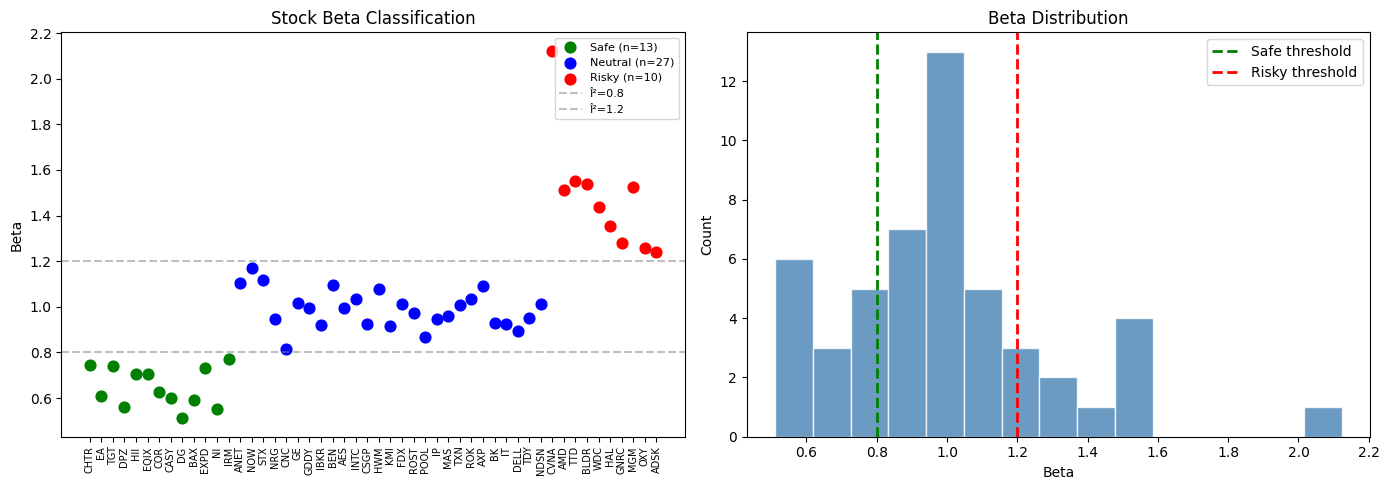

In [3]:
# Calculate daily returns
returns_df = price_df.pct_change().dropna()

# Market proxy: equal-weight average of all stocks
market_returns = returns_df.mean(axis=1)

# Calculate Beta for each ticker
betas = {}
market_var = market_returns.var()
for ticker in tickers:
    cov = returns_df[ticker].cov(market_returns)
    betas[ticker] = cov / (market_var + 1e-10)

beta_df = pd.DataFrame({'Ticker': list(betas.keys()), 'Beta': list(betas.values())})
beta_df = beta_df.sort_values('Beta').reset_index(drop=True)

# Classify into risk pools
risk_pools = {'Safe': [], 'Neutral': [], 'Risky': []}
beta_labels = {}
for ticker, beta in betas.items():
    if beta < 0.8:
        risk_pools['Safe'].append(ticker)
        beta_labels[ticker] = 'Safe'
    elif beta <= 1.2:
        risk_pools['Neutral'].append(ticker)
        beta_labels[ticker] = 'Neutral'
    else:
        risk_pools['Risky'].append(ticker)
        beta_labels[ticker] = 'Risky'

print("=== Risk-Profile Classification ===")
for profile, pool_tickers in risk_pools.items():
    pool_betas = [betas[t] for t in pool_tickers]
    print(f"\n{profile} Pool ({len(pool_tickers)} stocks, avg Î²={np.mean(pool_betas):.3f}):")
    for t in sorted(pool_tickers):
        print(f"  {t}: Î²={betas[t]:.3f} (GICS: {sector_map.get(t, 'N/A')})")

# Beta distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_map = {'Safe': 'green', 'Neutral': 'blue', 'Risky': 'red'}
for profile, pool_tickers in risk_pools.items():
    pool_betas = [betas[t] for t in pool_tickers]
    axes[0].scatter(pool_tickers, pool_betas, c=colors_map[profile], label=f'{profile} (n={len(pool_tickers)})', s=60)
axes[0].axhline(0.8, color='grey', linestyle='--', alpha=0.5, label='Î²=0.8')
axes[0].axhline(1.2, color='grey', linestyle='--', alpha=0.5, label='Î²=1.2')
axes[0].set_ylabel('Beta')
axes[0].set_title('Stock Beta Classification')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].legend(fontsize=8)

all_betas = list(betas.values())
axes[1].hist(all_betas, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0.8, color='green', linestyle='--', linewidth=2, label='Safe threshold')
axes[1].axvline(1.2, color='red', linestyle='--', linewidth=2, label='Risky threshold')
axes[1].set_xlabel('Beta')
axes[1].set_ylabel('Count')
axes[1].set_title('Beta Distribution')
axes[1].legend()
plt.tight_layout()
plt.show()

### 10-K Lexical Similarity Matrix Analysis

The lexical matrix captures **structural business similarity** from SEC 10-K filings.
Now indexed by Risk-Profile pools rather than GICS sectors.

Lexical Similarity Statistics (50 selected stocks):
  Mean: 0.0810
  Std:  0.0635
  Min:  0.0000
  Max:  0.6354
  Safe pool avg intra-similarity: 0.0708
  Neutral pool avg intra-similarity: 0.0971
  Risky pool avg intra-similarity: 0.0669

Text Sources (full universe):
  Yahoo: 78 stocks


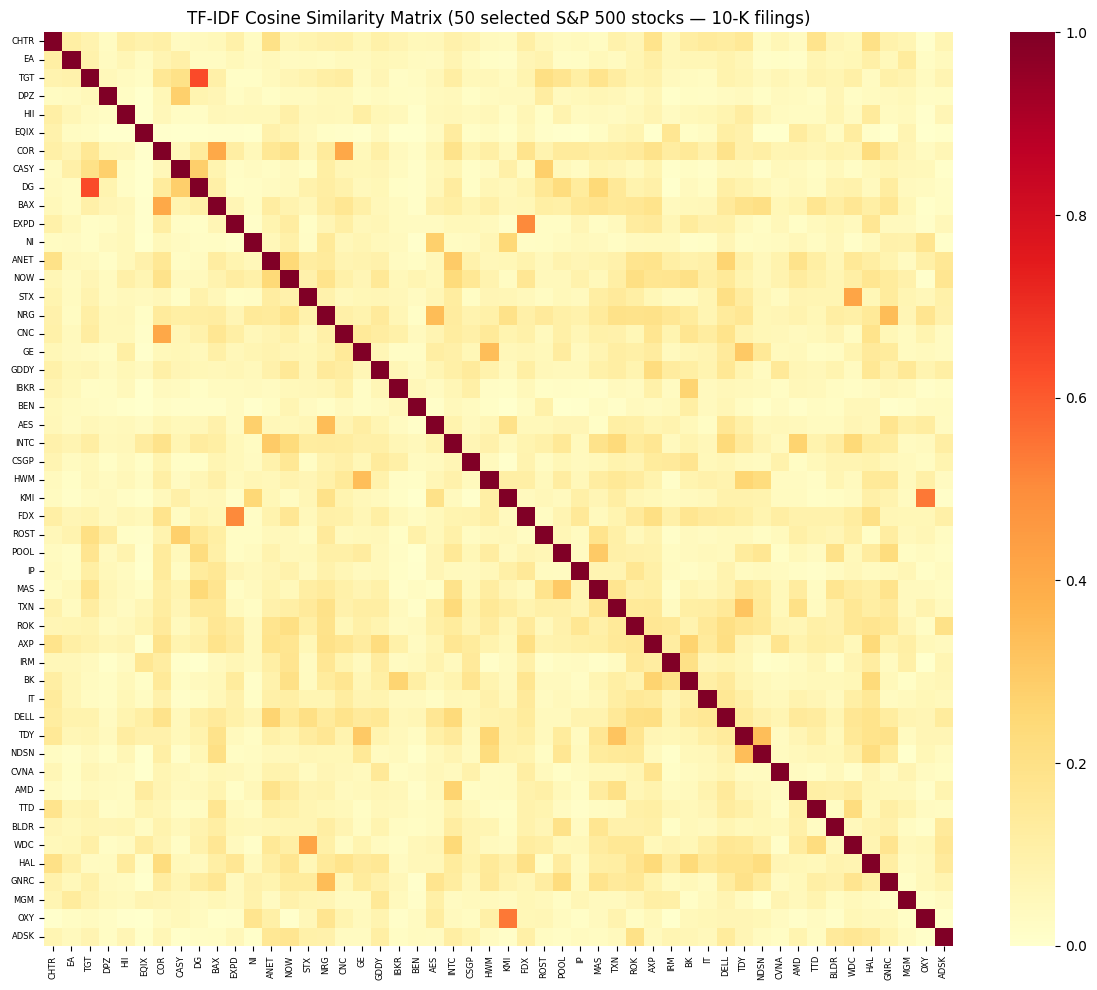

In [4]:
# Lexical matrix statistics (computed on the selected 50-stock submatrix)
upper = lexical_df.values[np.triu_indices_from(lexical_df.values, k=1)]
print(f"Lexical Similarity Statistics (50 selected stocks):")
print(f"  Mean: {np.mean(upper):.4f}")
print(f"  Std:  {np.std(upper):.4f}")
print(f"  Min:  {np.min(upper):.4f}")
print(f"  Max:  {np.max(upper):.4f}")

# Per-pool lexical similarity
for profile, pool_tickers in risk_pools.items():
    valid_t = [t for t in pool_tickers if t in lexical_df.index]
    if len(valid_t) > 1:
        sub = lexical_df.loc[valid_t, valid_t].values
        pool_upper = sub[np.triu_indices_from(sub, k=1)]
        print(f"  {profile} pool avg intra-similarity: {np.mean(pool_upper):.4f}")

# Check 10-K text source mix
try:
    with open("data/raw/sp500_100_10k_texts.json") as f:
        text_data = json.load(f)
    src_counts = Counter(text_data.get("sources", {}).values())
    print(f"\nText Sources (full universe):")
    for src, cnt in src_counts.most_common():
        print(f"  {src}: {cnt} stocks")
except FileNotFoundError:
    print("\n(10-K text source manifest not found — skipping source breakdown.)")

# Heatmap on the 50-stock submatrix
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(lexical_df, cmap='YlOrRd', ax=ax, xticklabels=True, yticklabels=True)
ax.set_title("TF-IDF Cosine Similarity Matrix (50 selected S&P 500 stocks — 10-K filings)", fontsize=12)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()


---
## Section 2: Risk-Profile Hierarchical Architecture

### The Hierarchy



### Why Risk-Profile Workers?

| Level | Agent | Manages | Objective |
|-------|-------|---------|-----------|
| **Top** | Manager | Capital allocation to risk profiles | **Global portfolio return** |
| **Bottom** | Safe Worker | Low-beta stock selection | **Minimize variance** |
| **Bottom** | Neutral Worker | Market-beta stock selection | **Maximize Sharpe** |
| **Bottom** | Risky Worker | High-beta stock selection | **Maximize alpha** |

### Final Portfolio Return
$$R_{global} = v_{safe} \\cdot R_{safe} + v_{neutral} \\cdot R_{neutral} + v_{risky} \\cdot R_{risky}$$

### Worker Environment — Profile-Specialized Rewards + Cash Asset
Each Worker manages stocks within its **risk-profile pool** plus a **Cash asset** (risk-free).
The Cash asset breaks the 1/N trap by giving agents an explicit "do nothing" option.
Weights are sampled via **Dirichlet distribution** instead of softmax to allow skewed allocations.

In [5]:
class WorkerEnv(gym.Env):
    """Worker agent: picks stocks within a risk-profile pool + Cash asset.
    
    Key fixes for 1/N convergence:
      1. Cash asset (action dim = n_assets + 1) — absorbs unused allocation
      2. Weights from Dirichlet sampling (in training loop) instead of softmax
      3. Hard turnover clipping (max 0.3 per step)
    """
    metadata = {"render_modes": []}
    TURNOVER_LIMIT = 0.3
    
    def __init__(self, price_df, lexical_matrix, tickers, profile="neutral",
                 window_size=30, lambda_penalty=0.1, gamma_penalty=0.01):
        super().__init__()
        self.profile = profile
        self.tickers = [t for t in tickers if t in price_df.columns and t in lexical_matrix.index]
        self.n_assets = len(self.tickers)
        self.n_total = self.n_assets + 1  # +1 for Cash
        self.prices = price_df[self.tickers].values
        self.returns_matrix = np.diff(self.prices, axis=0) / (self.prices[:-1] + 1e-8)
        self.lexical_matrix = np.nan_to_num(
            lexical_matrix.loc[self.tickers, self.tickers].values, nan=0.0)
        self.window_size = window_size
        self.lambda_penalty = lambda_penalty
        self.gamma_penalty = gamma_penalty
        
        if len(self.returns_matrix) > 1:
            self.cov_matrix = np.cov(self.returns_matrix.T)
        else:
            self.cov_matrix = np.eye(self.n_assets) * 0.01
        
        obs_dim = window_size * self.n_assets + self.n_total
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(low=0.01, high=10.0, shape=(self.n_total,), dtype=np.float32)
        
        self.current_step = 0
        self.portfolio_weights = np.ones(self.n_total) / self.n_total
        self.max_steps = len(self.prices) - window_size - 1
        self.portfolio_value = 1.0
        self.cum_return = 0.0
        self.recent_returns = []
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.portfolio_weights = np.ones(self.n_total) / self.n_total
        self.portfolio_value = 1.0
        self.cum_return = 0.0
        self.recent_returns = []
        return self._get_obs(), {}
    
    def step(self, action):
        w_full = np.abs(action) + 1e-8
        w_full = w_full / np.sum(w_full)
        
        # Hard turnover clipping
        delta = w_full - self.portfolio_weights
        turnover = np.sum(np.abs(delta))
        if turnover > self.TURNOVER_LIMIT:
            delta = delta * (self.TURNOVER_LIMIT / turnover)
            w_full = self.portfolio_weights + delta
            w_full = np.maximum(w_full, 0.0)
            w_full = w_full / np.sum(w_full)
            turnover = self.TURNOVER_LIMIT
        
        w_stocks = w_full[:self.n_assets]
        w_cash = w_full[self.n_assets]
        
        curr = self.prices[self.current_step]
        nxt = self.prices[self.current_step + 1]
        pr = nxt / (curr + 1e-8)
        stock_ret = np.dot(w_stocks, pr)
        port_ret = max(stock_ret + w_cash * 1.0, 1e-8)
        log_ret = np.log(port_ret)
        
        if np.sum(w_stocks) > 1e-8:
            w_norm = w_stocks / (np.sum(w_stocks) + 1e-8)
            sem_pen = np.dot(w_norm.T, np.dot(self.lexical_matrix, w_norm))
        else:
            sem_pen = 0.0
        
        if self.profile == "safe":
            if np.sum(w_stocks) > 1e-8:
                w_norm = w_stocks / (np.sum(w_stocks) + 1e-8)
                port_vol = np.sqrt(max(np.dot(w_norm.T, np.dot(self.cov_matrix, w_norm)), 1e-10))
            else:
                port_vol = 0.0
            reward = float(log_ret - self.lambda_penalty * sem_pen - 2.0 * port_vol)
        elif self.profile == "risky":
            reward = float(1.5 * log_ret - 0.5 * self.lambda_penalty * sem_pen)
        else:
            reward = float(log_ret - self.lambda_penalty * sem_pen - self.gamma_penalty * turnover)
        
        self.portfolio_weights = w_full
        self.portfolio_value *= port_ret
        self.cum_return += (port_ret - 1.0)
        self.recent_returns.append(port_ret - 1.0)
        if len(self.recent_returns) > 30:
            self.recent_returns.pop(0)
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        return self._get_obs(), reward, terminated, False, {
            'portfolio_return': port_ret, 'semantic_penalty': sem_pen,
            'turnover': turnover, 'weights': w_full.copy(),
            'stock_weights': w_stocks.copy(), 'cash_weight': w_cash,
            'cum_return': self.cum_return,
            'volatility': float(np.std(self.recent_returns)) if len(self.recent_returns) > 1 else 0.0}
    
    def _get_obs(self):
        s = self.current_step - self.window_size
        win = self.prices[s:self.current_step]
        norm = win / (win[0, :] + 1e-8)
        return np.concatenate([norm.flatten(), self.portfolio_weights]).astype(np.float32)
    
    def get_worker_state(self):
        """Return [cum_return, volatility] for Manager observation."""
        vol = float(np.std(self.recent_returns)) if len(self.recent_returns) > 1 else 0.0
        return np.array([self.cum_return, vol], dtype=np.float32)

print("WorkerEnv defined (Dirichlet + Cash + turnover clipping).")

WorkerEnv defined (Dirichlet + Cash + turnover clipping).


### Manager Environment â” Worker-Aware Observation
The Manager now observes **global market features** plus each Worker's **cumulative return** and **volatility**. It outputs a capital allocation vector V = [v_safe, v_neutral, v_risky].

In [6]:
class ManagerEnv(gym.Env):
    """Manager agent: allocates capital across 3 risk-profile Workers.

    UPGRADED VERSION (ported from Staged_MARL_Training.py):
      - Adds 7-dim market context (short_return, slow_return, short_vol, slow_vol,
        downside_ratio, current_drawdown, stress_score)
      - Reward includes stress_penalty + drawdown_penalty terms
      - extra_context_dim = n_pools + n_pools + 7  (= 13)

    Observation: [market_window(W*3), pool_weights(3), worker_cum_returns(3),
                  worker_volatilities(3), market_context(7)]
    Action:      raw 3-vector → normalised to capital allocation V = [v_safe, v_neutral, v_risky]
    Reward:      log(global_return) - turnover_penalty * turnover
                                    - stress_penalty * stress * stress_exposure
                                    - drawdown_penalty * dd_exposure
    """
    metadata = {"render_modes": []}

    def __init__(self, price_df, lexical_matrix, risk_pools,
                 window_size=30, fast_window=5, slow_window=20,
                 turnover_penalty=0.01, stress_penalty=0.20, drawdown_penalty=0.30):
        super().__init__()
        self.risk_pools = risk_pools
        self.pool_names = ['Safe', 'Neutral', 'Risky']
        self.n_pools = 3
        self.fast_window = fast_window
        self.slow_window = max(slow_window, fast_window + 1)
        self.turnover_penalty = turnover_penalty
        self.stress_penalty = stress_penalty
        self.drawdown_penalty = drawdown_penalty

        # Pool-level price index (mean of pool stocks)
        self.pool_prices = {}
        for name in self.pool_names:
            pool_tickers = [t for t in risk_pools.get(name, []) if t in price_df.columns]
            if pool_tickers:
                self.pool_prices[name] = price_df[pool_tickers].mean(axis=1).values
            else:
                self.pool_prices[name] = np.ones(len(price_df))

        self.window_size = window_size
        self.all_prices = np.column_stack([self.pool_prices[p] for p in self.pool_names])
        self.market_proxy = price_df.mean(axis=1).values
        self.market_returns = np.diff(self.market_proxy) / (self.market_proxy[:-1] + 1e-8)

        # Intra-pool lexical similarity (for diagnostics)
        self.pool_sim = np.zeros(self.n_pools)
        for i, name in enumerate(self.pool_names):
            pool_tickers = [t for t in risk_pools.get(name, []) if t in lexical_matrix.index]
            if len(pool_tickers) > 1:
                sim = lexical_matrix.loc[pool_tickers, pool_tickers].values
                mask = np.triu(np.ones_like(sim, dtype=bool), k=1)
                self.pool_sim[i] = np.nanmean(sim[mask])

        # extra_context_dim drives EIIENetwork wiring
        self.market_feature_dim = 7
        self.extra_context_dim = self.n_pools + self.n_pools + self.market_feature_dim  # = 13
        obs_dim = window_size * self.n_pools + self.n_pools + self.extra_context_dim
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(self.n_pools,), dtype=np.float32)

        self.current_step = 0
        self.pool_weights = np.ones(self.n_pools) / self.n_pools
        self.max_steps = len(self.all_prices) - window_size - 1
        self.worker_cum_returns = np.zeros(self.n_pools, dtype=np.float32)
        self.worker_volatilities = np.zeros(self.n_pools, dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.pool_weights = np.ones(self.n_pools) / self.n_pools
        self.worker_cum_returns = np.zeros(self.n_pools, dtype=np.float32)
        self.worker_volatilities = np.zeros(self.n_pools, dtype=np.float32)
        return self._get_obs(), {}

    def update_worker_states(self, worker_states):
        for i, name in enumerate(self.pool_names):
            if name in worker_states:
                self.worker_cum_returns[i] = worker_states[name][0]
                self.worker_volatilities[i] = worker_states[name][1]

    def step(self, action, worker_returns=None):
        v = np.abs(action) + 1e-8
        v = v / np.sum(v)

        if worker_returns is not None:
            global_ret = sum(v[i] * worker_returns.get(name, 1.0)
                             for i, name in enumerate(self.pool_names))
            global_ret = max(global_ret, 1e-8)
        else:
            curr = self.all_prices[self.current_step]
            nxt = self.all_prices[self.current_step + 1]
            pr = nxt / (curr + 1e-8)
            global_ret = max(np.dot(v, pr), 1e-8)

        log_ret = np.log(global_ret)
        turnover = np.sum(np.abs(v - self.pool_weights))

        market_context = self._get_market_context()
        current_drawdown = float(market_context[-2])
        stress_score = float(market_context[-1])
        neutral_idx = self.pool_names.index('Neutral')
        risky_idx = self.pool_names.index('Risky')

        stress_exposure = 0.35 * v[risky_idx] + 0.15 * v[neutral_idx]
        drawdown_exposure = max(current_drawdown - 0.08, 0.0) * (0.50 * v[risky_idx] + 0.25 * v[neutral_idx])
        reward = float(
            log_ret
            - self.turnover_penalty * turnover
            - self.stress_penalty * stress_score * stress_exposure
            - self.drawdown_penalty * drawdown_exposure
        )

        self.pool_weights = v
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        return self._get_obs(), reward, terminated, False, {
            'pool_weights': v.copy(), 'global_return': global_ret,
            'stress_score': stress_score, 'current_drawdown': current_drawdown}

    def _get_market_context(self):
        recent_prices = self.market_proxy[max(0, self.current_step - self.slow_window):self.current_step + 1]
        short_prices = self.market_proxy[max(0, self.current_step - self.fast_window):self.current_step + 1]
        recent_returns = self.market_returns[max(0, self.current_step - self.slow_window):self.current_step]
        short_returns = self.market_returns[max(0, self.current_step - self.fast_window):self.current_step]

        short_return = float(short_prices[-1] / (short_prices[0] + 1e-8) - 1.0) if len(short_prices) > 1 else 0.0
        slow_return = float(recent_prices[-1] / (recent_prices[0] + 1e-8) - 1.0) if len(recent_prices) > 1 else 0.0
        short_vol = float(np.std(short_returns) * np.sqrt(252)) if len(short_returns) > 1 else 0.0
        slow_vol = float(np.std(recent_returns) * np.sqrt(252)) if len(recent_returns) > 1 else 0.0
        downside_ratio = float(np.mean(recent_returns < 0.0)) if len(recent_returns) > 0 else 0.0
        rolling_peak = float(np.max(recent_prices)) if len(recent_prices) > 0 else 1.0
        current_drawdown = float((rolling_peak - recent_prices[-1]) / (rolling_peak + 1e-8)) if len(recent_prices) > 0 else 0.0
        stress_score = np.clip(
            (short_vol / (slow_vol + 1e-8) - 1.0)
            + 2.0 * current_drawdown
            + downside_ratio,
            0.0, 3.0)
        return np.array([short_return, slow_return, short_vol, slow_vol,
                         downside_ratio, current_drawdown, stress_score], dtype=np.float32)

    def _get_obs(self):
        s = self.current_step - self.window_size
        win = self.all_prices[s:self.current_step]
        norm = win / (win[0, :] + 1e-8)
        return np.concatenate([
            norm.flatten(), self.pool_weights,
            self.worker_cum_returns, self.worker_volatilities,
            self._get_market_context()
        ]).astype(np.float32)

print("ManagerEnv defined (Worker-aware obs + market stress context, extra_context_dim=13).")


ManagerEnv defined (Worker-aware obs + market stress context, extra_context_dim=13).


---
## Section 3: EIIE Network & Concurrent REINFORCE Training

The **EIIE** (Ensemble of Identical Independent Evaluators) network:
- Shares Conv1D weights across assets and prevents ticker memorization
- Includes **Portfolio-Vector Memory** (PVM)
- Each of the 4 agents (Manager + 3 Workers) has its own EIIE instance

### Concurrent Training Loop
All 4 agents step simultaneously at each timestep. The Manager observes Worker states
and outputs capital allocation V. Workers focus on their local pool objectives.

In [7]:
class EIIENetwork(nn.Module):
    """EIIE with shared Conv1D weights, LayerNorm, Dropout(0.1) + Dirichlet output.

    UPGRADED VERSION (ported from Staged_MARL_Training.py):
      - Adds optional extra_context_dim concatenated into the FC head
      - LayerNorm + Dropout(0.1) for training stability
      - Output: Dirichlet alpha = Softplus + 1.0 (alpha > 1 → unimodal Dirichlet)
    """
    def __init__(self, n_assets, window_size, n_price_assets=None, extra_context_dim=0):
        super().__init__()
        self.n_assets = n_assets
        self.n_price_assets = n_price_assets or n_assets
        self.extra_context_dim = extra_context_dim
        self.conv1 = nn.Conv1d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, 3, padding=1)
        fc_in = self.n_price_assets * 32 + n_assets + extra_context_dim
        self.fc1 = nn.Linear(fc_in, 64)
        self.ln1 = nn.LayerNorm(64)
        self.dropout = nn.Dropout(0.1)
        self.fc2 = nn.Linear(64, n_assets)

    def forward(self, pw, pvm, extra_context=None):
        feats = []
        for i in range(self.n_price_assets):
            x = pw[:, i, :].unsqueeze(1)
            x = F.relu(self.conv1(x))
            x = F.relu(self.conv2(x))
            x = x.mean(dim=2)
            feats.append(x)
        inputs = feats + [pvm]
        if self.extra_context_dim:
            if extra_context is None:
                raise ValueError("extra_context is required when extra_context_dim > 0")
            inputs.append(extra_context)
        c = torch.cat(inputs, dim=1)
        x = self.dropout(F.relu(self.ln1(self.fc1(c))))
        return F.softplus(self.fc2(x)) + 1.0

print("EIIENetwork defined (LayerNorm + Dropout + extra_context support).")


EIIENetwork defined (LayerNorm + Dropout + extra_context support).


In [8]:
# ==============================================================
# REINFORCE HELPER + EMA BASELINES (shared by concurrent & staged)
# ==============================================================
_ema_baselines = {}  # per-network running avg of episode returns (variance reduction)


def tensor_from_numpy(array_like, device=DEVICE):
    return torch.as_tensor(array_like, dtype=torch.float32, device=device)


def reinforce_update(log_probs, rewards, entropies, optimizer, net, entropy_bonus, gamma=0.99):
    """REINFORCE with EMA baseline + entropy bonus."""
    if not log_probs:
        return
    G, rets = 0, []
    for r in reversed(rewards):
        G = r + gamma * G
        rets.insert(0, G)
    rets = torch.tensor(rets, dtype=torch.float32, device=DEVICE)

    net_id = id(net)
    ep_mean = float(rets.mean())
    if net_id not in _ema_baselines:
        _ema_baselines[net_id] = ep_mean
    else:
        _ema_baselines[net_id] = 0.9 * _ema_baselines[net_id] + 0.1 * ep_mean
    baseline = _ema_baselines[net_id]

    rets = rets - baseline
    std = rets.std()
    if std > 1e-8:
        rets = rets / (std + 1e-8)

    policy_loss = sum(-lp * g for lp, g in zip(log_probs, rets))
    ent_loss = -entropy_bonus * sum(entropies)
    total_loss = policy_loss + ent_loss
    optimizer.zero_grad()
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
    optimizer.step()


# ==============================================================
# CONCURRENT TRAINING
# ==============================================================
def train_concurrent(manager_env, worker_envs, n_episodes=200, lr=3e-3,
                     max_steps=200, verbose=False):
    """All 4 agents step and learn simultaneously each episode."""
    pool_names = ['Safe', 'Neutral', 'Risky']
    m_n = manager_env.action_space.shape[0]
    m_ws = manager_env.window_size
    manager_net = EIIENetwork(m_n, m_ws,
                              extra_context_dim=manager_env.extra_context_dim).to(DEVICE)
    manager_opt = optim.Adam(manager_net.parameters(), lr=lr)
    m_scheduler = optim.lr_scheduler.CosineAnnealingLR(manager_opt, T_max=n_episodes, eta_min=5e-4)

    worker_nets, worker_opts, worker_schedulers = {}, {}, {}
    for name in pool_names:
        if name in worker_envs:
            env = worker_envs[name]
            worker_nets[name] = EIIENetwork(env.n_total, env.window_size,
                                            n_price_assets=env.n_assets).to(DEVICE)
            worker_opts[name] = optim.Adam(worker_nets[name].parameters(), lr=lr)
            worker_schedulers[name] = optim.lr_scheduler.CosineAnnealingLR(
                worker_opts[name], T_max=n_episodes, eta_min=5e-4)

    hist = {'manager_rewards': [], 'worker_rewards': {n: [] for n in pool_names},
            'global_returns': [], 'allocations': []}

    for ep in range(n_episodes):
        progress = ep / max(n_episodes - 1, 1)
        entropy_bonus = 0.05 * (1.0 - progress) + 0.005 * progress
        turnover_limit = 1.0 * (1.0 - progress) + 0.5 * progress
        for name in pool_names:
            if name in worker_envs:
                worker_envs[name].TURNOVER_LIMIT = turnover_limit

        m_obs, _ = manager_env.reset()
        w_obs = {}
        for name in pool_names:
            if name in worker_envs:
                w_obs[name], _ = worker_envs[name].reset()

        m_lps, m_rews, m_entropies = [], [], []
        w_lps = {n: [] for n in pool_names}
        w_rews = {n: [] for n in pool_names}
        w_entropies = {n: [] for n in pool_names}
        done, steps = False, 0

        while not done and steps < max_steps:
            worker_states = {}
            for name in pool_names:
                if name in worker_envs:
                    worker_states[name] = worker_envs[name].get_worker_state()
            manager_env.update_worker_states(worker_states)
            m_obs = manager_env._get_obs()

            obs_dim = m_ws * m_n
            m_pw = tensor_from_numpy(m_obs[:obs_dim].reshape(m_n, m_ws)).unsqueeze(0)
            m_pvm = tensor_from_numpy(m_obs[obs_dim:obs_dim+m_n]).unsqueeze(0)
            m_context = tensor_from_numpy(m_obs[obs_dim+m_n:]).unsqueeze(0)
            m_alpha = manager_net(m_pw, m_pvm, m_context).squeeze()
            m_alpha = torch.clamp(m_alpha, min=1.01, max=100.0)
            m_dist = torch.distributions.Dirichlet(m_alpha)
            m_action = m_dist.sample()
            m_lps.append(m_dist.log_prob(m_action))
            m_entropies.append(m_dist.entropy())

            worker_returns = {}
            for name in pool_names:
                if name not in worker_envs:
                    continue
                env = worker_envs[name]
                net = worker_nets[name]
                obs = w_obs[name]
                w_obs_dim = env.window_size * env.n_assets
                w_pw = tensor_from_numpy(obs[:w_obs_dim].reshape(env.n_assets, env.window_size)).unsqueeze(0)
                w_pvm = tensor_from_numpy(obs[w_obs_dim:w_obs_dim+env.n_total]).unsqueeze(0)
                w_alpha = net(w_pw, w_pvm).squeeze()
                w_alpha = torch.clamp(w_alpha, min=1.01, max=100.0)
                w_dist = torch.distributions.Dirichlet(w_alpha)
                w_action = w_dist.sample()
                w_lps[name].append(w_dist.log_prob(w_action))
                w_entropies[name].append(w_dist.entropy())

                obs_new, w_reward, w_term, _, w_info = env.step(w_action.detach().cpu().numpy())
                w_obs[name] = obs_new
                w_rews[name].append(w_reward)
                worker_returns[name] = w_info.get('portfolio_return', 1.0)
                if w_term:
                    done = True

            m_obs_new, m_reward, m_term, _, m_info = manager_env.step(
                m_action.detach().cpu().numpy(), worker_returns=worker_returns)
            m_obs = m_obs_new
            m_rews.append(m_reward)
            if m_term:
                done = True
            steps += 1

        # Updates
        reinforce_update(m_lps, m_rews, m_entropies, manager_opt, manager_net, entropy_bonus)
        m_scheduler.step()
        for name in pool_names:
            if name not in worker_nets or not w_lps[name]:
                continue
            reinforce_update(w_lps[name], w_rews[name], w_entropies[name],
                             worker_opts[name], worker_nets[name], entropy_bonus)
            worker_schedulers[name].step()

        hist['manager_rewards'].append(sum(m_rews))
        hist['global_returns'].append(float(m_info.get('global_return', 1.0)) if m_info else 1.0)
        for name in pool_names:
            hist['worker_rewards'][name].append(sum(w_rews[name]) if w_rews[name] else 0)
        if m_info and 'pool_weights' in m_info:
            hist['allocations'].append(m_info['pool_weights'].tolist())

        if verbose and (ep + 1) % 20 == 0:
            alloc_str = ""
            if hist['allocations']:
                a = hist['allocations'][-1]
                alloc_str = f" | V=[{a[0]:.2f},{a[1]:.2f},{a[2]:.2f}]"
            lr_now = manager_opt.param_groups[0]['lr']
            print(f"  Ep {ep+1:3d} | R={sum(m_rews):+.3f}{alloc_str}"
                  f" | lr={lr_now:.5f} ent={entropy_bonus:.4f}"
                  f" | S={sum(w_rews.get('Safe',[])):+.3f}"
                  f" N={sum(w_rews.get('Neutral',[])):+.3f}"
                  f" R={sum(w_rews.get('Risky',[])):+.3f}")

    return manager_net, worker_nets, hist


# ==============================================================
# STAGED (CURRICULUM) TRAINING
# ==============================================================
def train_staged(manager_env, worker_envs,
                 phase1_episodes=200, phase2_episodes=160, phase3_episodes=80,
                 lr=3e-3, max_steps=200, verbose=True):
    """
    Curriculum/Staged Training:
      Phase 1: Workers train; Manager FROZEN at 1/3 equal allocation.
      Phase 2: Manager trains; Workers FROZEN at learned policies.
      Phase 3: Joint fine-tuning (all unfrozen, LR=5e-4).
    """
    pool_names = ['Safe', 'Neutral', 'Risky']

    m_n = manager_env.action_space.shape[0]
    m_ws = manager_env.window_size
    manager_net = EIIENetwork(m_n, m_ws,
                              extra_context_dim=manager_env.extra_context_dim).to(DEVICE)

    worker_nets, worker_opts, worker_schedulers = {}, {}, {}
    for name in pool_names:
        if name in worker_envs:
            env = worker_envs[name]
            worker_nets[name] = EIIENetwork(env.n_total, env.window_size,
                                            n_price_assets=env.n_assets).to(DEVICE)

    hist = {'phase': [], 'manager_rewards': [], 'worker_rewards': {n: [] for n in pool_names},
            'global_returns': [], 'allocations': [], 'phase_boundaries': []}

    # ----- PHASE 1: Workers learn, Manager fixed at equal weights -----
    if verbose:
        print("\n" + "=" * 60)
        print("PHASE 1: Training Workers (Manager FROZEN at 1/3 equal)")
        print("=" * 60)
    for name in pool_names:
        if name in worker_nets:
            worker_opts[name] = optim.Adam(worker_nets[name].parameters(), lr=lr)
            worker_schedulers[name] = optim.lr_scheduler.CosineAnnealingLR(
                worker_opts[name], T_max=phase1_episodes, eta_min=5e-4)

    fixed_allocation = np.array([1.0/3, 1.0/3, 1.0/3])
    for ep in range(phase1_episodes):
        progress = ep / max(phase1_episodes - 1, 1)
        entropy_bonus = 0.05 * (1.0 - progress) + 0.005 * progress
        turnover_limit = 1.0 * (1.0 - progress) + 0.5 * progress
        for name in pool_names:
            if name in worker_envs:
                worker_envs[name].TURNOVER_LIMIT = turnover_limit

        m_obs, _ = manager_env.reset()
        w_obs = {}
        for name in pool_names:
            if name in worker_envs:
                w_obs[name], _ = worker_envs[name].reset()

        w_lps = {n: [] for n in pool_names}
        w_rews = {n: [] for n in pool_names}
        w_entropies = {n: [] for n in pool_names}
        m_rews = []
        done, steps = False, 0

        while not done and steps < max_steps:
            v = fixed_allocation.copy()

            worker_returns = {}
            for name in pool_names:
                if name not in worker_envs:
                    continue
                env = worker_envs[name]
                net = worker_nets[name]
                obs = w_obs[name]
                w_obs_dim = env.window_size * env.n_assets
                w_pw = tensor_from_numpy(obs[:w_obs_dim].reshape(env.n_assets, env.window_size)).unsqueeze(0)
                w_pvm = tensor_from_numpy(obs[w_obs_dim:w_obs_dim+env.n_total]).unsqueeze(0)
                w_alpha = net(w_pw, w_pvm).squeeze()
                w_alpha = torch.clamp(w_alpha, min=1.01, max=100.0)
                w_dist = torch.distributions.Dirichlet(w_alpha)
                w_action = w_dist.sample()
                w_lps[name].append(w_dist.log_prob(w_action))
                w_entropies[name].append(w_dist.entropy())
                obs_new, w_reward, w_term, _, w_info = env.step(w_action.detach().cpu().numpy())
                w_obs[name] = obs_new
                w_rews[name].append(w_reward)
                worker_returns[name] = w_info.get('portfolio_return', 1.0)
                if w_term:
                    done = True

            m_obs_new, m_reward, m_term, _, m_info = manager_env.step(v, worker_returns=worker_returns)
            m_obs = m_obs_new
            m_rews.append(m_reward)
            if m_term:
                done = True
            steps += 1

        for name in pool_names:
            if name not in worker_nets or not w_lps[name]:
                continue
            reinforce_update(w_lps[name], w_rews[name], w_entropies[name],
                             worker_opts[name], worker_nets[name], entropy_bonus)
            worker_schedulers[name].step()

        hist['phase'].append(1)
        hist['manager_rewards'].append(sum(m_rews))
        for name in pool_names:
            hist['worker_rewards'][name].append(sum(w_rews[name]) if w_rews[name] else 0)
        hist['allocations'].append(fixed_allocation.tolist())
        if verbose and (ep + 1) % 50 == 0:
            w_str = " | ".join(f"{n}={sum(w_rews.get(n, [])):+.3f}" for n in pool_names if n in worker_envs)
            print(f"  P1 Ep {ep+1:3d}/{phase1_episodes} | {w_str} | ent={entropy_bonus:.4f}")
    hist['phase_boundaries'].append(len(hist['manager_rewards']))

    # ----- PHASE 2: Manager learns, Workers frozen -----
    if verbose:
        print("\n" + "=" * 60)
        print("PHASE 2: Training Manager (Workers FROZEN)")
        print("=" * 60)
    manager_opt = optim.Adam(manager_net.parameters(), lr=lr)
    m_scheduler = optim.lr_scheduler.CosineAnnealingLR(manager_opt, T_max=phase2_episodes, eta_min=5e-4)
    for name in pool_names:
        if name in worker_nets:
            for p in worker_nets[name].parameters():
                p.requires_grad = False

    for ep in range(phase2_episodes):
        progress = ep / max(phase2_episodes - 1, 1)
        entropy_bonus = 0.04 * (1.0 - progress) + 0.005 * progress

        m_obs, _ = manager_env.reset()
        w_obs = {}
        for name in pool_names:
            if name in worker_envs:
                w_obs[name], _ = worker_envs[name].reset()
                worker_envs[name].TURNOVER_LIMIT = 0.5

        m_lps, m_rews, m_entropies = [], [], []
        w_rews_track = {n: [] for n in pool_names}
        done, steps = False, 0

        while not done and steps < max_steps:
            worker_states = {}
            for name in pool_names:
                if name in worker_envs:
                    worker_states[name] = worker_envs[name].get_worker_state()
            manager_env.update_worker_states(worker_states)
            m_obs = manager_env._get_obs()

            obs_dim = m_ws * m_n
            m_pw = tensor_from_numpy(m_obs[:obs_dim].reshape(m_n, m_ws)).unsqueeze(0)
            m_pvm = tensor_from_numpy(m_obs[obs_dim:obs_dim+m_n]).unsqueeze(0)
            m_context = tensor_from_numpy(m_obs[obs_dim+m_n:]).unsqueeze(0)
            m_alpha = manager_net(m_pw, m_pvm, m_context).squeeze()
            m_alpha = torch.clamp(m_alpha, min=1.01, max=100.0)
            m_dist = torch.distributions.Dirichlet(m_alpha)
            m_action = m_dist.sample()
            m_lps.append(m_dist.log_prob(m_action))
            m_entropies.append(m_dist.entropy())

            worker_returns = {}
            for name in pool_names:
                if name not in worker_envs:
                    continue
                env = worker_envs[name]
                net = worker_nets[name]
                obs = w_obs[name]
                w_obs_dim = env.window_size * env.n_assets
                w_pw = tensor_from_numpy(obs[:w_obs_dim].reshape(env.n_assets, env.window_size)).unsqueeze(0)
                w_pvm = tensor_from_numpy(obs[w_obs_dim:w_obs_dim+env.n_total]).unsqueeze(0)
                with torch.no_grad():
                    w_alpha = net(w_pw, w_pvm).squeeze().detach().cpu().numpy()
                    w_w = dirichlet_mode(w_alpha)
                obs_new, _, w_term, _, w_info = env.step(w_w)
                w_obs[name] = obs_new
                worker_returns[name] = w_info.get('portfolio_return', 1.0)
                w_rews_track[name].append(w_info.get('portfolio_return', 1.0) - 1.0)
                if w_term:
                    done = True

            m_obs_new, m_reward, m_term, _, m_info = manager_env.step(
                m_action.detach().cpu().numpy(), worker_returns=worker_returns)
            m_obs = m_obs_new
            m_rews.append(m_reward)
            if m_term:
                done = True
            steps += 1

        reinforce_update(m_lps, m_rews, m_entropies, manager_opt, manager_net, entropy_bonus)
        m_scheduler.step()

        hist['phase'].append(2)
        hist['manager_rewards'].append(sum(m_rews))
        for name in pool_names:
            hist['worker_rewards'][name].append(sum(w_rews_track[name]) if w_rews_track[name] else 0)
        if m_info and 'pool_weights' in m_info:
            hist['allocations'].append(m_info['pool_weights'].tolist())
        if verbose and (ep + 1) % 40 == 0:
            alloc = m_info['pool_weights'] if m_info and 'pool_weights' in m_info else fixed_allocation
            print(f"  P2 Ep {ep+1:3d}/{phase2_episodes} | MgrR={sum(m_rews):+.3f}"
                  f" | V=[{alloc[0]:.2f},{alloc[1]:.2f},{alloc[2]:.2f}]")
    hist['phase_boundaries'].append(len(hist['manager_rewards']))

    # Unfreeze workers for phase 3
    for name in pool_names:
        if name in worker_nets:
            for p in worker_nets[name].parameters():
                p.requires_grad = True

    # ----- PHASE 3: Joint fine-tuning -----
    if verbose:
        print("\n" + "=" * 60)
        print("PHASE 3: Joint Fine-Tuning (all agents unfrozen)")
        print("=" * 60)
    fine_lr = 5e-4
    for pg in manager_opt.param_groups:
        pg['lr'] = fine_lr
    for name in pool_names:
        if name in worker_opts:
            for pg in worker_opts[name].param_groups:
                pg['lr'] = fine_lr

    for ep in range(phase3_episodes):
        progress = ep / max(phase3_episodes - 1, 1)
        entropy_bonus = 0.01 * (1.0 - progress) + 0.002 * progress
        for name in pool_names:
            if name in worker_envs:
                worker_envs[name].TURNOVER_LIMIT = 0.5

        m_obs, _ = manager_env.reset()
        w_obs = {}
        for name in pool_names:
            if name in worker_envs:
                w_obs[name], _ = worker_envs[name].reset()

        m_lps, m_rews, m_entropies = [], [], []
        w_lps = {n: [] for n in pool_names}
        w_rews = {n: [] for n in pool_names}
        w_entropies = {n: [] for n in pool_names}
        done, steps = False, 0

        while not done and steps < max_steps:
            worker_states = {}
            for name in pool_names:
                if name in worker_envs:
                    worker_states[name] = worker_envs[name].get_worker_state()
            manager_env.update_worker_states(worker_states)
            m_obs = manager_env._get_obs()

            obs_dim = m_ws * m_n
            m_pw = tensor_from_numpy(m_obs[:obs_dim].reshape(m_n, m_ws)).unsqueeze(0)
            m_pvm = tensor_from_numpy(m_obs[obs_dim:obs_dim+m_n]).unsqueeze(0)
            m_context = tensor_from_numpy(m_obs[obs_dim+m_n:]).unsqueeze(0)
            m_alpha = manager_net(m_pw, m_pvm, m_context).squeeze()
            m_alpha = torch.clamp(m_alpha, min=1.01, max=100.0)
            m_dist = torch.distributions.Dirichlet(m_alpha)
            m_action = m_dist.sample()
            m_lps.append(m_dist.log_prob(m_action))
            m_entropies.append(m_dist.entropy())

            worker_returns = {}
            for name in pool_names:
                if name not in worker_envs:
                    continue
                env = worker_envs[name]
                net = worker_nets[name]
                obs = w_obs[name]
                w_obs_dim = env.window_size * env.n_assets
                w_pw = tensor_from_numpy(obs[:w_obs_dim].reshape(env.n_assets, env.window_size)).unsqueeze(0)
                w_pvm = tensor_from_numpy(obs[w_obs_dim:w_obs_dim+env.n_total]).unsqueeze(0)
                w_alpha = net(w_pw, w_pvm).squeeze()
                w_alpha = torch.clamp(w_alpha, min=1.01, max=100.0)
                w_dist = torch.distributions.Dirichlet(w_alpha)
                w_action = w_dist.sample()
                w_lps[name].append(w_dist.log_prob(w_action))
                w_entropies[name].append(w_dist.entropy())
                obs_new, w_reward, w_term, _, w_info = env.step(w_action.detach().cpu().numpy())
                w_obs[name] = obs_new
                w_rews[name].append(w_reward)
                worker_returns[name] = w_info.get('portfolio_return', 1.0)
                if w_term:
                    done = True

            m_obs_new, m_reward, m_term, _, m_info = manager_env.step(
                m_action.detach().cpu().numpy(), worker_returns=worker_returns)
            m_obs = m_obs_new
            m_rews.append(m_reward)
            if m_term:
                done = True
            steps += 1

        reinforce_update(m_lps, m_rews, m_entropies, manager_opt, manager_net, entropy_bonus)
        for name in pool_names:
            if name not in worker_nets or not w_lps[name]:
                continue
            reinforce_update(w_lps[name], w_rews[name], w_entropies[name],
                             worker_opts[name], worker_nets[name], entropy_bonus)

        hist['phase'].append(3)
        hist['manager_rewards'].append(sum(m_rews))
        for name in pool_names:
            hist['worker_rewards'][name].append(sum(w_rews[name]) if w_rews[name] else 0)
        if m_info and 'pool_weights' in m_info:
            hist['allocations'].append(m_info['pool_weights'].tolist())
        if verbose and (ep + 1) % 20 == 0:
            alloc = m_info['pool_weights'] if m_info and 'pool_weights' in m_info else np.ones(3)/3
            print(f"  P3 Ep {ep+1:3d}/{phase3_episodes} | MgrR={sum(m_rews):+.3f}"
                  f" | V=[{alloc[0]:.2f},{alloc[1]:.2f},{alloc[2]:.2f}]")
    hist['phase_boundaries'].append(len(hist['manager_rewards']))

    total_eps = phase1_episodes + phase2_episodes + phase3_episodes
    if verbose:
        print(f"\n  STAGED TRAINING COMPLETE: {total_eps} total episodes "
              f"(P1={phase1_episodes}, P2={phase2_episodes}, P3={phase3_episodes})")
    return manager_net, worker_nets, hist


print("Training functions defined: train_concurrent, train_staged (+reinforce_update + EMA baseline).")


Training functions defined: train_concurrent, train_staged (+reinforce_update + EMA baseline).


---
## Section 4: Risk Metrics

### CVaR (Conditional Value at Risk) at 95%
$$CVaR_{95\%} = E[R \mid R \leq VaR_{95\%}]$$

### Sortino Ratio
$$Sortino = \\frac{\\bar{R}}{\\sigma_{downside}}$$

### Calmar Ratio
$$Calmar = \\frac{R_{annualized}}{MaxDrawdown}$$

In [9]:
def compute_max_drawdown(returns):
    cum = np.cumprod(1 + returns)
    peak = np.maximum.accumulate(cum)
    dd = (peak - cum) / peak
    return float(np.max(dd)) if len(dd) > 0 else 0.0

def compute_cvar(returns, alpha=0.05):
    sorted_r = np.sort(returns)
    cutoff = max(int(alpha * len(sorted_r)), 1)
    return float(np.mean(sorted_r[:cutoff]))

def compute_sortino(returns, target=0):
    excess = returns - target
    downside = returns[returns < target]
    if len(downside) == 0:
        return float('inf')
    down_std = np.std(downside)
    if down_std < 1e-10:
        return float('inf')
    return float(np.mean(excess) / down_std * np.sqrt(252))

def compute_calmar(returns, max_dd=None):
    if max_dd is None:
        max_dd = compute_max_drawdown(returns)
    ann_ret = np.mean(returns) * 252
    return float(ann_ret / max_dd) if max_dd > 0 else 0.0

def compute_hhi(weights):
    return float(np.sum(weights ** 2))

def compute_effective_n(weights):
    hhi = compute_hhi(weights)
    return float(1.0 / hhi) if hhi > 0 else 0.0

def drawdown_decomposition(returns):
    cum = np.cumprod(1 + returns)
    peak = np.maximum.accumulate(cum)
    dd = (peak - cum) / peak
    drawdowns = []
    in_dd, dd_start, max_depth, trough_idx = False, 0, 0, 0
    for i in range(len(dd)):
        if dd[i] > 0.001:
            if not in_dd:
                dd_start, in_dd, max_depth, trough_idx = i, True, dd[i], i
            elif dd[i] > max_depth:
                max_depth, trough_idx = dd[i], i
        else:
            if in_dd:
                drawdowns.append({'start': dd_start, 'trough': trough_idx, 'end': i,
                    'depth': float(max_depth), 'duration': i - dd_start, 'recovery': i - trough_idx})
                in_dd = False
    if in_dd:
        drawdowns.append({'start': dd_start, 'trough': trough_idx, 'end': len(dd)-1,
            'depth': float(max_depth), 'duration': len(dd)-1-dd_start, 'recovery': len(dd)-1-trough_idx})
    return drawdowns

def dirichlet_mode(alpha):
    """Mode of Dirichlet (concentrated) when all alpha_i > 1; else fallback to mean."""
    K = len(alpha)
    if np.all(alpha > 1.0) and np.sum(alpha) > K:
        return (alpha - 1.0) / (np.sum(alpha) - K)
    else:
        return alpha / np.sum(alpha)

def evaluate_concurrent(manager_env, worker_envs, manager_net, worker_nets, max_steps=200):
    """Evaluate full hierarchy using Dirichlet MODE (concentrated, deterministic).
    Works for both concurrent- and staged-trained networks (they share signatures)."""
    pool_names = ['Safe', 'Neutral', 'Risky']
    m_obs, _ = manager_env.reset()
    w_obs = {}
    for name in pool_names:
        if name in worker_envs:
            w_obs[name], _ = worker_envs[name].reset()

    global_returns, worker_returns_hist = [], {n: [] for n in pool_names}
    allocations, done, steps = [], False, 0
    m_n = manager_env.action_space.shape[0]
    m_ws = manager_env.window_size

    while not done and steps < max_steps:
        worker_states = {}
        for name in pool_names:
            if name in worker_envs:
                worker_states[name] = worker_envs[name].get_worker_state()
        manager_env.update_worker_states(worker_states)
        m_obs = manager_env._get_obs()

        obs_dim = m_ws * m_n
        m_pw = tensor_from_numpy(m_obs[:obs_dim].reshape(m_n, m_ws)).unsqueeze(0)
        m_pvm = tensor_from_numpy(m_obs[obs_dim:obs_dim+m_n]).unsqueeze(0)
        m_context = tensor_from_numpy(m_obs[obs_dim+m_n:]).unsqueeze(0)
        with torch.no_grad():
            m_alpha = manager_net(m_pw, m_pvm, m_context).squeeze().detach().cpu().numpy()
            v = dirichlet_mode(m_alpha)

        w_rets = {}
        for name in pool_names:
            if name not in worker_envs:
                continue
            env = worker_envs[name]
            net = worker_nets[name]
            w_n_total = env.n_total
            w_n_price = env.n_assets
            w_ws_l = env.window_size
            obs = w_obs[name]
            w_od = w_ws_l * w_n_price
            w_pw = tensor_from_numpy(obs[:w_od].reshape(w_n_price, w_ws_l)).unsqueeze(0)
            w_pvm = tensor_from_numpy(obs[w_od:w_od+w_n_total]).unsqueeze(0)
            with torch.no_grad():
                w_alpha = net(w_pw, w_pvm).squeeze().detach().cpu().numpy()
                w_w = dirichlet_mode(w_alpha)
            obs_new, _, w_term, _, w_info = env.step(w_w)
            w_obs[name] = obs_new
            w_rets[name] = w_info.get('portfolio_return', 1.0)
            worker_returns_hist[name].append(w_rets[name] - 1.0)
            if w_term:
                done = True

        m_obs_new, _, m_term, _, m_info = manager_env.step(v, worker_returns=w_rets)
        m_obs = m_obs_new

        global_ret = sum(v[i] * w_rets.get(name, 1.0) for i, name in enumerate(pool_names))
        global_returns.append(global_ret - 1.0)
        allocations.append(v.copy())

        if m_term:
            done = True
        steps += 1

    global_returns = np.array(global_returns)
    avg_alloc = np.mean(allocations, axis=0) if allocations else np.ones(3)/3

    result = {
        'global_returns': global_returns,
        'total_return': float(np.prod(1 + global_returns) - 1),
        'sharpe': float(np.mean(global_returns) / (np.std(global_returns) + 1e-8) * np.sqrt(252)),
        'max_drawdown': compute_max_drawdown(global_returns),
        'cvar_95': compute_cvar(global_returns),
        'sortino': compute_sortino(global_returns),
        'calmar': compute_calmar(global_returns),
        'avg_allocation': avg_alloc,
        'worker_results': {}
    }
    for name in pool_names:
        wr = np.array(worker_returns_hist[name]) if worker_returns_hist[name] else np.array([0.0])
        result['worker_results'][name] = {
            'total_return': float(np.prod(1 + wr) - 1),
            'sharpe': float(np.mean(wr) / (np.std(wr) + 1e-8) * np.sqrt(252)),
            'max_drawdown': compute_max_drawdown(wr),
        }
    return result

print("Risk metrics + evaluate_concurrent defined (handles staged- and concurrent-trained nets).")


Risk metrics + evaluate_concurrent defined (handles staged- and concurrent-trained nets).


---
## Section 5: Concurrent Training â€” 3 Risk-Profile Workers + Manager

Training all 4 agents simultaneously:
1. **Manager** allocates capital across Safe/Neutral/Risky pools
2. **Safe Worker**  minimizes variance in low-beta stocks  
3. **Neutral Worker**  maximizes Sharpe in market-beta stocks
4. **Risky Worker**  maximizes alpha in high-beta stocks

In [10]:
t0 = time.time()

print("=" * 60)
print("CONCURRENT TRAINING: Manager + 3 Risk-Profile Workers")
print("=" * 60)

# Worker environments — lambda_penalty=0.35 (matches Staged_MARL_Training.py)
worker_envs = {}
for profile in ['Safe', 'Neutral', 'Risky']:
    pool_tickers = risk_pools[profile]
    if len(pool_tickers) >= 2:
        worker_envs[profile] = WorkerEnv(
            price_df, lexical_df, pool_tickers,
            profile=profile.lower(), window_size=30,
            lambda_penalty=0.35, gamma_penalty=0.01)
        print(f"  {profile} Worker: {len(pool_tickers)} stocks (lambda=0.35)")
    else:
        print(f"  {profile} Worker: SKIPPED (only {len(pool_tickers)} stocks)")

manager_env = ManagerEnv(price_df, lexical_df, risk_pools, window_size=30)
print(f"  Manager: allocating across {len(worker_envs)} risk pools "
      f"(extra_context_dim={manager_env.extra_context_dim})")

manager_net, worker_nets, train_hist = train_concurrent(
    manager_env, worker_envs, n_episodes=200, verbose=True)

print(f"\nConcurrent training complete. ({time.time()-t0:.1f}s)")


CONCURRENT TRAINING: Manager + 3 Risk-Profile Workers
  Safe Worker: 13 stocks (lambda=0.35)
  Neutral Worker: 27 stocks (lambda=0.35)
  Risky Worker: 10 stocks (lambda=0.35)
  Manager: allocating across 3 risk pools (extra_context_dim=13)
  Ep  20 | R=-4.405 | V=[0.30,0.30,0.40] | lr=0.00294 ent=0.0457 | S=-16.765 N=-12.124 R=-7.267
  Ep  40 | R=-3.678 | V=[0.79,0.17,0.04] | lr=0.00276 ent=0.0412 | S=-16.836 N=-12.074 R=-7.076
  Ep  60 | R=-3.674 | V=[0.60,0.38,0.02] | lr=0.00248 ent=0.0367 | S=-16.771 N=-12.136 R=-7.167
  Ep  80 | R=-3.477 | V=[0.71,0.05,0.24] | lr=0.00214 ent=0.0321 | S=-16.476 N=-12.240 R=-7.174
  Ep 100 | R=-3.587 | V=[0.42,0.32,0.26] | lr=0.00175 ent=0.0276 | S=-16.463 N=-12.105 R=-7.200
  Ep 120 | R=-3.940 | V=[0.18,0.62,0.20] | lr=0.00136 ent=0.0231 | S=-16.146 N=-11.958 R=-7.306
  Ep 140 | R=-3.539 | V=[0.52,0.19,0.28] | lr=0.00102 ent=0.0186 | S=-16.006 N=-11.692 R=-7.230
  Ep 160 | R=-3.611 | V=[0.85,0.12,0.03] | lr=0.00074 ent=0.0140 | S=-16.096 N=-11.399 R

### Concurrent Evaluation
Evaluate the full hierarchy: Manager allocating to Workers, each Worker selecting stocks.

In [11]:
# Evaluate concurrent system
eval_result = evaluate_concurrent(manager_env, worker_envs, manager_net, worker_nets, max_steps=200)

print("=== Global Portfolio ===")
print(f"  Return: {eval_result['total_return']:.4f}")
print(f"  Sharpe: {eval_result['sharpe']:.4f}")
print(f"  MaxDD:  {eval_result['max_drawdown']:.4f}")
print(f"  CVaR:   {eval_result['cvar_95']:.4f}")
print(f"  Sortino: {eval_result['sortino']:.4f}")
print(f"  Calmar: {eval_result['calmar']:.4f}")

print(f"\n=== Manager Allocation ===")
for i, name in enumerate(['Safe', 'Neutral', 'Risky']):
    print(f"  {name}: {eval_result['avg_allocation'][i]:.4f}")

print(f"\n=== Worker Performance ===")
for name, wr in eval_result['worker_results'].items():
    print(f"  {name}: Return={wr['total_return']:.4f}, Sharpe={wr['sharpe']:.4f}, MaxDD={wr['max_drawdown']:.4f}")

=== Global Portfolio ===
  Return: 0.0540
  Sharpe: 0.5553
  MaxDD:  0.1171
  CVaR:   -0.0211
  Sortino: 0.7438
  Calmar: 0.6459

=== Manager Allocation ===
  Safe: 0.4175
  Neutral: 0.4346
  Risky: 0.1479

=== Worker Performance ===
  Safe: Return=0.0926, Sharpe=0.8781, MaxDD=0.0851
  Neutral: Return=-0.0107, Sharpe=-0.0206, MaxDD=0.1646
  Risky: Return=0.1257, Sharpe=0.7466, MaxDD=0.1977


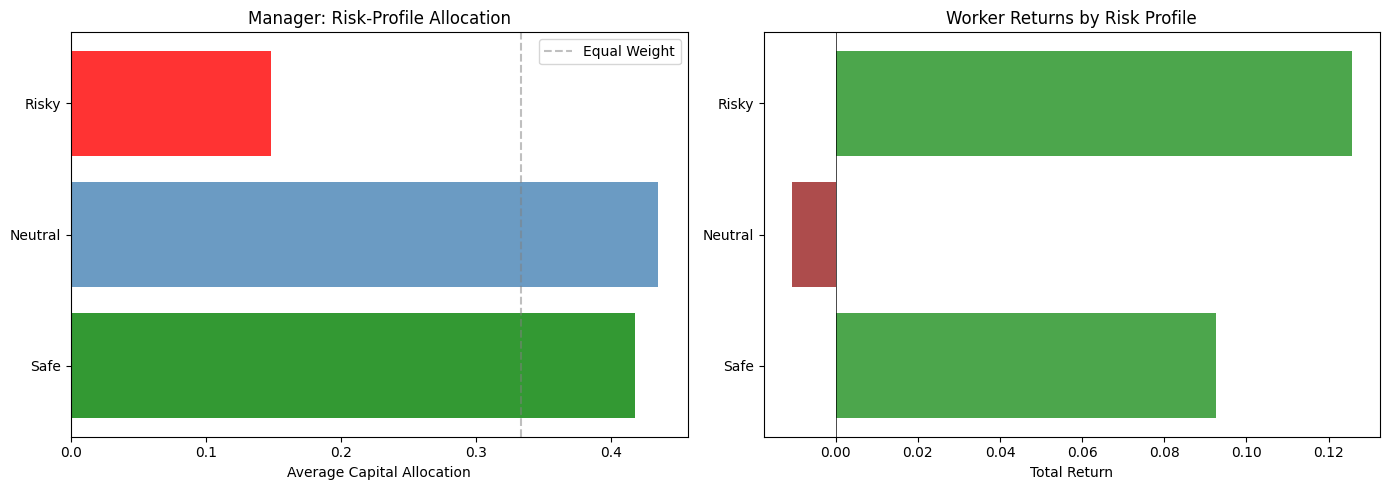

In [12]:
# Manager allocation and Worker returns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pool_names_plot = ['Safe', 'Neutral', 'Risky']
colors_plot = ['green', 'steelblue', 'red']

# Allocation weights
alloc = eval_result['avg_allocation']
axes[0].barh(pool_names_plot, alloc, color=colors_plot, alpha=0.8)
axes[0].axvline(1.0/3, color='grey', linestyle='--', alpha=0.5, label='Equal Weight')
axes[0].set_xlabel('Average Capital Allocation')
axes[0].set_title('Manager: Risk-Profile Allocation')
axes[0].legend()

# Worker returns
w_returns = [eval_result['worker_results'][n]['total_return'] for n in pool_names_plot]
bar_colors = ['green' if r > 0 else 'darkred' for r in w_returns]
axes[1].barh(pool_names_plot, w_returns, color=bar_colors, alpha=0.7)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Total Return')
axes[1].set_title('Worker Returns by Risk Profile')

plt.tight_layout()
plt.show()

---
## Section 5b: Staged (Curriculum) Training — Workers → Manager → Joint

Concurrent training updates all four agents at every step, which can be unstable because the
Manager is being asked to allocate across moving-target Workers. **Staged training** breaks the
dependency by following a 3-phase curriculum:

| Phase | Trains | Frozen | Episodes | Purpose |
|-------|--------|--------|----------|---------|
| **1** | Workers | Manager (1/3 each) | 200 | Workers learn stable, profile-specific trading policies before the allocator gets a vote. |
| **2** | Manager | Workers (locked) | 160 | Allocator learns capital weights against already-competent Workers. |
| **3** | Joint (all unfrozen) | — | 80 | Fine-tuning at LR=5e-4 to coordinate the hierarchy end-to-end. |

Both regimes use the same upgraded `EIIENetwork` (LayerNorm + Dropout) and `ManagerEnv`
(market-stress context + drawdown/stress reward penalties). The same `evaluate_concurrent`
inference routine works for both since they share the network signature.


In [13]:
t_staged = time.time()

# Fresh environments for staged training (workers carry mutable TURNOVER_LIMIT state)
staged_worker_envs = {}
for profile in ['Safe', 'Neutral', 'Risky']:
    pool_tickers = risk_pools[profile]
    if len(pool_tickers) >= 2:
        staged_worker_envs[profile] = WorkerEnv(
            price_df, lexical_df, pool_tickers,
            profile=profile.lower(), window_size=30,
            lambda_penalty=0.35, gamma_penalty=0.01)

staged_manager_env = ManagerEnv(price_df, lexical_df, risk_pools, window_size=30)

staged_manager_net, staged_worker_nets, staged_hist = train_staged(
    staged_manager_env, staged_worker_envs,
    phase1_episodes=200, phase2_episodes=160, phase3_episodes=80,
    verbose=True)

print(f"\nStaged training complete. ({time.time()-t_staged:.1f}s)")



PHASE 1: Training Workers (Manager FROZEN at 1/3 equal)
  P1 Ep  50/200 | Safe=-16.709 | Neutral=-11.931 | Risky=-7.582 | ent=0.0389


KeyboardInterrupt: 

In [ ]:
# Inference-only evaluation of the staged hierarchy
staged_eval = evaluate_concurrent(staged_manager_env, staged_worker_envs,
                                  staged_manager_net, staged_worker_nets, max_steps=200)

print("=== STAGED — Global Portfolio ===")
for k in ['total_return', 'sharpe', 'sortino', 'max_drawdown', 'cvar_95', 'calmar']:
    print(f"  {k:>15}: {staged_eval[k]:.4f}")
print("\n=== STAGED — Manager Allocation ===")
for i, name in enumerate(['Safe', 'Neutral', 'Risky']):
    print(f"  {name}: {staged_eval['avg_allocation'][i]:.4f}")
print("\n=== STAGED — Worker Performance ===")
for name, wr in staged_eval['worker_results'].items():
    print(f"  {name}: Return={wr['total_return']:.4f}, "
          f"Sharpe={wr['sharpe']:.4f}, MaxDD={wr['max_drawdown']:.4f}")


In [ ]:
# Side-by-side comparison: Staged vs Concurrent
def _fmt(v, pct=False):
    if pct:
        return f"{v*100:+.2f}%"
    return f"{v:+.4f}"

rows = [
    ("Total Return",   _fmt(staged_eval['total_return'], pct=True),  _fmt(eval_result['total_return'], pct=True)),
    ("Sharpe",         _fmt(staged_eval['sharpe']),                  _fmt(eval_result['sharpe'])),
    ("Sortino",        _fmt(staged_eval['sortino']),                 _fmt(eval_result['sortino'])),
    ("Max Drawdown",   _fmt(staged_eval['max_drawdown'], pct=True),  _fmt(eval_result['max_drawdown'], pct=True)),
    ("CVaR 95%",       _fmt(staged_eval['cvar_95'], pct=True),       _fmt(eval_result['cvar_95'], pct=True)),
    ("Calmar",         _fmt(staged_eval['calmar']),                  _fmt(eval_result['calmar'])),
]

print("=" * 72)
print(f"{'Metric':<20} {'Staged':>22} {'Concurrent':>22}")
print("-" * 72)
for name, s, c in rows:
    print(f"{name:<20} {s:>22} {c:>22}")
print("-" * 72)
print(f"{'Manager allocation':<20} {'Safe / Neutral / Risky':>22} {'Safe / Neutral / Risky':>22}")
sa = staged_eval['avg_allocation']
ca = eval_result['avg_allocation']
print(f"{'  weights (avg)':<20} "
      f"{f'{sa[0]:.2f} / {sa[1]:.2f} / {sa[2]:.2f}':>22} "
      f"{f'{ca[0]:.2f} / {ca[1]:.2f} / {ca[2]:.2f}':>22}")
print("=" * 72)


In [ ]:
# Drawdown comparison figure: equity curves + drawdown overlays for Staged vs Concurrent
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

s_ret = staged_eval['global_returns']
c_ret = eval_result['global_returns']

s_eq = np.cumprod(1 + s_ret)
c_eq = np.cumprod(1 + c_ret)
axes[0].plot(s_eq, color='#1f77b4', lw=1.8, label=f"Staged (Sharpe={staged_eval['sharpe']:.2f})")
axes[0].plot(c_eq, color='#ff7f0e', lw=1.8, label=f"Concurrent (Sharpe={eval_result['sharpe']:.2f})")
axes[0].axhline(1.0, color='grey', ls='--', alpha=0.5)
axes[0].set_ylabel('Equity (start = 1.0)')
axes[0].set_title('Equity Curves — Staged vs Concurrent MARL')
axes[0].legend(); axes[0].grid(alpha=0.3)

s_peak = np.maximum.accumulate(s_eq); s_dd = (s_peak - s_eq) / s_peak
c_peak = np.maximum.accumulate(c_eq); c_dd = (c_peak - c_eq) / c_peak
axes[1].fill_between(range(len(s_dd)), 0, -s_dd, color='#1f77b4', alpha=0.35,
                     label=f"Staged MaxDD={staged_eval['max_drawdown']*100:.2f}%")
axes[1].fill_between(range(len(c_dd)), 0, -c_dd, color='#ff7f0e', alpha=0.35,
                     label=f"Concurrent MaxDD={eval_result['max_drawdown']*100:.2f}%")
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Trading day (eval window)')
axes[1].set_title('Drawdown Overlay')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('drawdown_comparison.png', dpi=140, bbox_inches='tight')
plt.show()
print("Saved: drawdown_comparison.png")


---
## Section 6: Walk-Forward Validation

Rolling retrain across 4 market regimes using the concurrent architecture.

In [ ]:
wf_windows = [
    ("2015-2018 -> 2019 (Bull)",     "2015-01-01", "2019-01-01", "2019-01-01", "2020-01-01"),
    ("2015-2019 -> 2020 (COVID)",    "2015-01-01", "2020-01-01", "2020-01-01", "2021-01-01"),
    ("2015-2020 -> 2021 (Recovery)", "2015-01-01", "2021-01-01", "2021-01-01", "2022-01-01"),
    ("2015-2021 -> 2022 (Bear)",     "2015-01-01", "2022-01-01", "2022-01-01", "2023-01-01"),
]

wf_results = {}
for wf_name, train_s, train_e, test_s, test_e in wf_windows:
    print(f"\n--- {wf_name} ---")
    train_prices = price_df.loc[train_s:train_e]
    test_prices = price_df.loc[test_s:test_e]

    if len(train_prices) < 60 or len(test_prices) < 20:
        print(f"  Skipping — insufficient data")
        continue

    wf_worker_envs = {}
    for profile in ['Safe', 'Neutral', 'Risky']:
        pool_tickers = risk_pools[profile]
        valid_t = [t for t in pool_tickers if t in train_prices.columns]
        if len(valid_t) >= 2:
            wf_worker_envs[profile] = WorkerEnv(
                train_prices, lexical_df, valid_t,
                profile=profile.lower(), window_size=30,
                lambda_penalty=0.35, gamma_penalty=0.01)

    wf_mgr_env = ManagerEnv(train_prices, lexical_df, risk_pools, window_size=30)
    wf_mgr_net, wf_w_nets, _ = train_concurrent(wf_mgr_env, wf_worker_envs, n_episodes=100, verbose=False)

    test_worker_envs = {}
    for profile in ['Safe', 'Neutral', 'Risky']:
        pool_tickers = risk_pools[profile]
        valid_t = [t for t in pool_tickers if t in test_prices.columns]
        if len(valid_t) >= 2:
            test_worker_envs[profile] = WorkerEnv(
                test_prices, lexical_df, valid_t,
                profile=profile.lower(), window_size=30,
                lambda_penalty=0.35, gamma_penalty=0.01)

    test_mgr_env = ManagerEnv(test_prices, lexical_df, risk_pools, window_size=30)
    wf_eval = evaluate_concurrent(test_mgr_env, test_worker_envs, wf_mgr_net, wf_w_nets, max_steps=200)

    wf_results[wf_name] = wf_eval
    print(f"  Return: {wf_eval['total_return']:.4f}, Sharpe: {wf_eval['sharpe']:.4f}, "
          f"MaxDD: {wf_eval['max_drawdown']:.4f}")

print("\nWalk-Forward Complete!")



--- 2015-2018 â†’ 2019 (Bull) ---
  Return: 0.1234, Sharpe: 1.5159, MaxDD: 0.0507

--- 2015-2019 â†’ 2020 (COVID) ---
  Return: 0.1921, Sharpe: 0.8180, MaxDD: 0.3163

--- 2015-2020 â†’ 2021 (Recovery) ---
  Return: 0.1888, Sharpe: 1.9677, MaxDD: 0.0428

--- 2015-2021 â†’ 2022 (Bear) ---
  Return: -0.1466, Sharpe: -0.6171, MaxDD: 0.2578

Walk-Forward Complete!


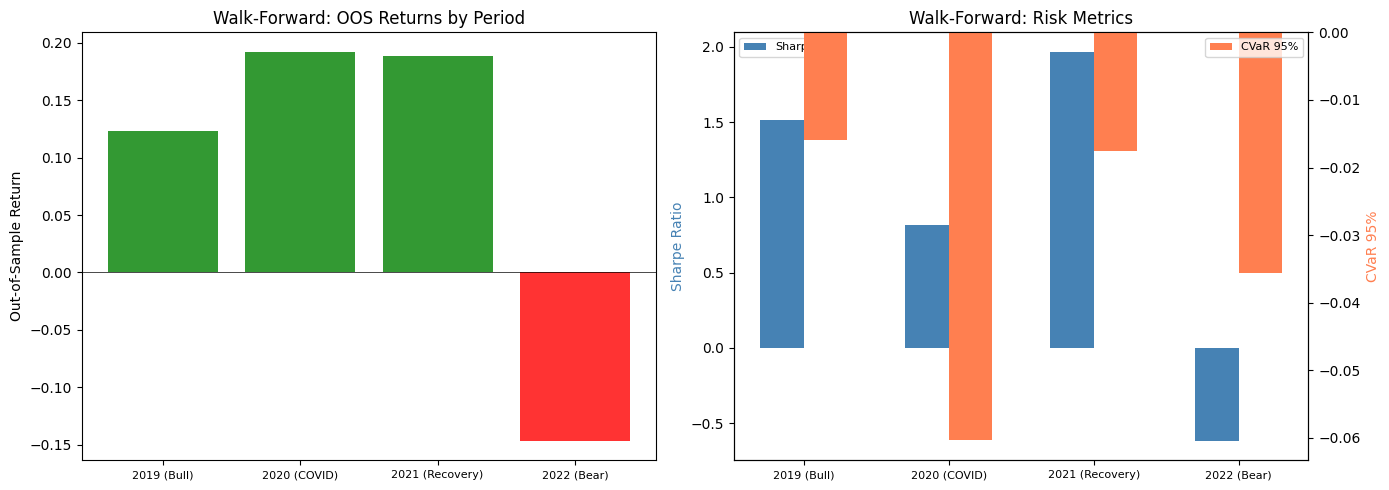

In [ ]:
# Walk-Forward visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wf_names = list(wf_results.keys())
wf_returns = [wf_results[w]['total_return'] for w in wf_names]
colors = ['green' if r > 0 else 'red' for r in wf_returns]
short_names = [w.split('->')[1].strip()[:20] if '->' in w else w[:20] for w in wf_names]
axes[0].bar(range(len(wf_names)), wf_returns, color=colors, alpha=0.8)
axes[0].set_xticks(range(len(wf_names)))
axes[0].set_xticklabels(short_names, fontsize=8)
axes[0].set_ylabel('Out-of-Sample Return')
axes[0].set_title('Walk-Forward: OOS Returns by Period')
axes[0].axhline(0, color='black', linewidth=0.5)

sharpe_vals = [wf_results[w]['sharpe'] for w in wf_names]
cvar_vals = [wf_results[w]['cvar_95'] for w in wf_names]
x = np.arange(len(wf_names))
axes[1].bar(x - 0.15, sharpe_vals, 0.3, label='Sharpe', color='steelblue')
ax2 = axes[1].twinx()
ax2.bar(x + 0.15, cvar_vals, 0.3, label='CVaR 95%', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names, fontsize=8)
axes[1].set_ylabel('Sharpe Ratio', color='steelblue')
ax2.set_ylabel('CVaR 95%', color='coral')
axes[1].set_title('Walk-Forward: Risk Metrics')
axes[1].legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()


---
## Section 7: Lambda Ablation — Concurrent vs Staged

We sweep the lexical-penalty strength λ ∈ {0.0, 0.1, 0.35, 0.5, 1.0} and run the **full
training pipeline twice** for each value: once with concurrent training (200 episodes) and
once with staged training (200 + 160 + 80 = 440 episodes). For each (λ, regime) pair we
record Return, Sharpe, Sortino, MaxDD and the Manager's average allocation to each pool.

A higher λ pushes the Workers (and via the Manager's reward, the allocator) away from
business-similar baskets. The ablation reveals whether semantic diversification is
information the agents can convert into out-of-sample edge.


In [ ]:
lambdas = [0.0, 0.1, 0.35, 0.5, 1.0]
ablation_results = {'concurrent': {}, 'staged': {}}

t_abl = time.time()
for lam in lambdas:
    print(f"\n==== Lambda = {lam} ====")

    # ---- Concurrent ----
    abl_w = {}
    for profile in ['Safe', 'Neutral', 'Risky']:
        pt = risk_pools[profile]
        if len(pt) >= 2:
            abl_w[profile] = WorkerEnv(price_df, lexical_df, pt,
                                       profile=profile.lower(), window_size=30,
                                       lambda_penalty=lam, gamma_penalty=0.01)
    abl_m = ManagerEnv(price_df, lexical_df, risk_pools, window_size=30)
    cn_net, cw_net, _ = train_concurrent(abl_m, abl_w, n_episodes=200, verbose=False)
    cn_eval = evaluate_concurrent(abl_m, abl_w, cn_net, cw_net, max_steps=200)
    ablation_results['concurrent'][lam] = cn_eval
    print(f"  Concurrent  Return={cn_eval['total_return']:+.4f}  Sharpe={cn_eval['sharpe']:+.3f}"
          f"  MaxDD={cn_eval['max_drawdown']:.3f}  V={[f'{a:.2f}' for a in cn_eval['avg_allocation']]}")

    # ---- Staged ----
    abl_w_s = {}
    for profile in ['Safe', 'Neutral', 'Risky']:
        pt = risk_pools[profile]
        if len(pt) >= 2:
            abl_w_s[profile] = WorkerEnv(price_df, lexical_df, pt,
                                         profile=profile.lower(), window_size=30,
                                         lambda_penalty=lam, gamma_penalty=0.01)
    abl_m_s = ManagerEnv(price_df, lexical_df, risk_pools, window_size=30)
    sn_net, sw_net, _ = train_staged(abl_m_s, abl_w_s,
                                     phase1_episodes=200, phase2_episodes=160,
                                     phase3_episodes=80, verbose=False)
    sn_eval = evaluate_concurrent(abl_m_s, abl_w_s, sn_net, sw_net, max_steps=200)
    ablation_results['staged'][lam] = sn_eval
    print(f"  Staged      Return={sn_eval['total_return']:+.4f}  Sharpe={sn_eval['sharpe']:+.3f}"
          f"  MaxDD={sn_eval['max_drawdown']:.3f}  V={[f'{a:.2f}' for a in sn_eval['avg_allocation']]}")

print(f"\nAblation complete. ({time.time()-t_abl:.1f}s)")



Training with Î» = 0.0...
  Return=0.0046, Sharpe=0.1107, Alloc=['0.38', '0.35', '0.26']

Training with Î» = 0.1...
  Return=0.0094, Sharpe=0.1552, Alloc=['0.36', '0.43', '0.21']

Training with Î» = 0.5...
  Return=-0.0646, Sharpe=-0.4813, Alloc=['0.22', '0.29', '0.49']

Training with Î» = 1.0...
  Return=-0.0138, Sharpe=-0.0587, Alloc=['0.32', '0.34', '0.34']

Ablation Complete!


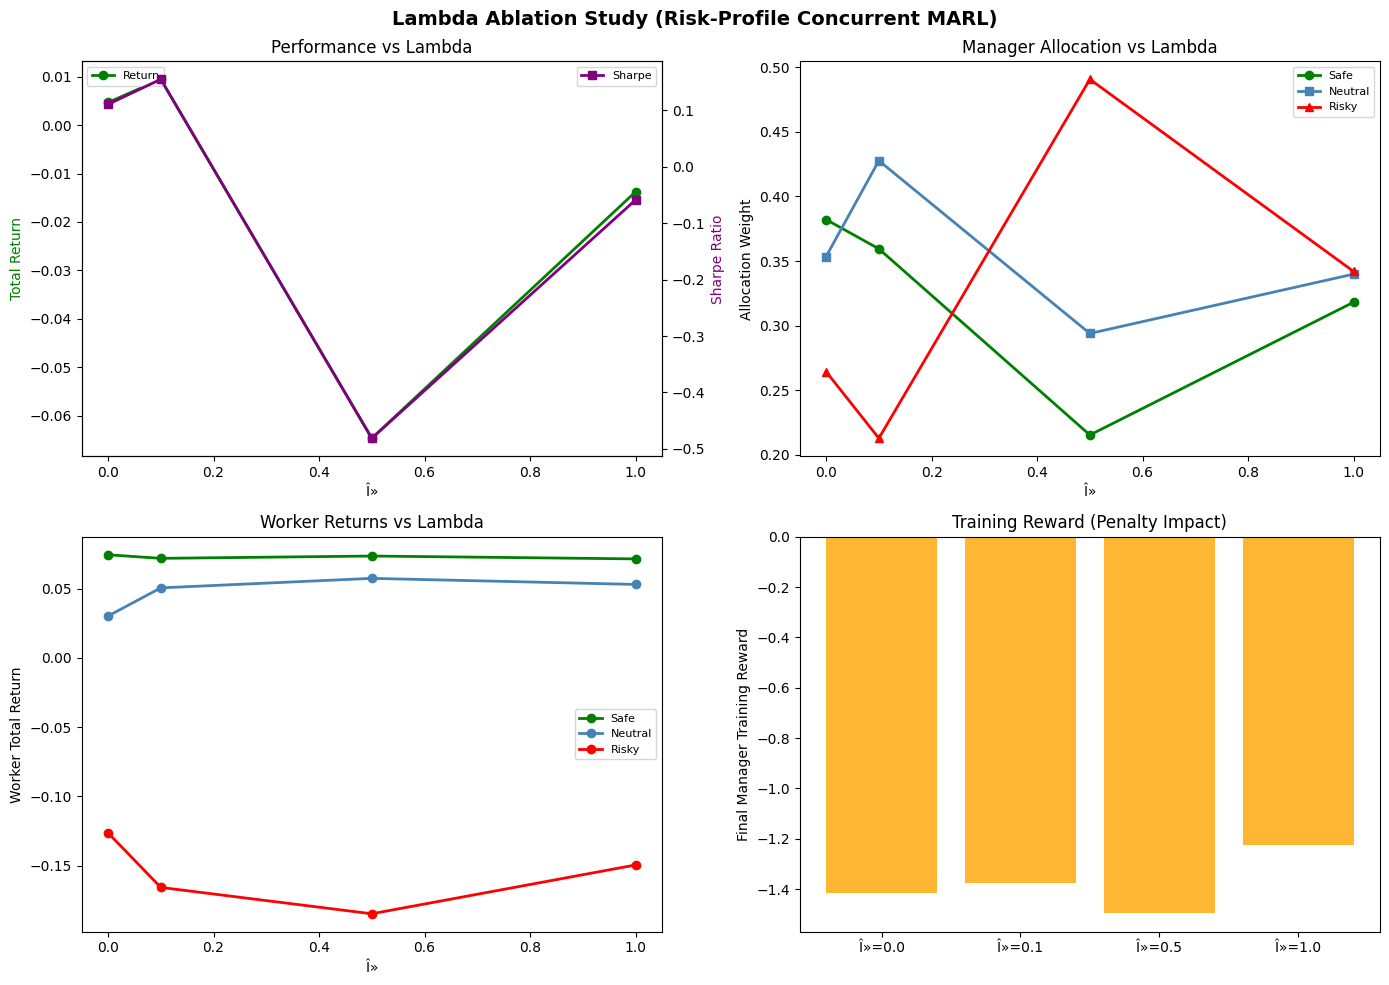

In [ ]:
# 3x2 ablation comparison: rows = Sharpe / Return / MaxDD ; cols = metric vs Manager-Safe %
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Lambda Ablation — Concurrent vs Staged Training", fontsize=14, fontweight='bold')

lam_vals = lambdas
def _series(reg, key):
    return [ablation_results[reg][l][key] for l in lam_vals]
def _safe_alloc(reg):
    return [ablation_results[reg][l]['avg_allocation'][0] for l in lam_vals]

# Row 1: Sharpe
ax = axes[0, 0]
ax.plot(lam_vals, _series('staged', 'sharpe'),     'o-', color='steelblue', lw=2, label='Staged')
ax.plot(lam_vals, _series('concurrent', 'sharpe'), 's-', color='darkorange', lw=2, label='Concurrent')
ax.set_xlabel('Lambda'); ax.set_ylabel('Sharpe Ratio')
ax.set_title('Sharpe vs Lambda'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(lam_vals, _safe_alloc('staged'),     'o-', color='steelblue', lw=2, label='Staged')
ax.plot(lam_vals, _safe_alloc('concurrent'), 's-', color='darkorange', lw=2, label='Concurrent')
ax.set_xlabel('Lambda'); ax.set_ylabel('Safe-pool allocation (avg)')
ax.set_title('Manager Safe-Allocation vs Lambda'); ax.legend(); ax.grid(alpha=0.3)

# Row 2: Return
ax = axes[1, 0]
ax.plot(lam_vals, _series('staged', 'total_return'),     'o-', color='steelblue', lw=2, label='Staged')
ax.plot(lam_vals, _series('concurrent', 'total_return'), 's-', color='darkorange', lw=2, label='Concurrent')
ax.set_xlabel('Lambda'); ax.set_ylabel('Total Return')
ax.set_title('Return vs Lambda'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 1]
neut_s = [ablation_results['staged'][l]['avg_allocation'][1] for l in lam_vals]
neut_c = [ablation_results['concurrent'][l]['avg_allocation'][1] for l in lam_vals]
ax.plot(lam_vals, neut_s, 'o-', color='steelblue', lw=2, label='Staged Neutral')
ax.plot(lam_vals, neut_c, 's-', color='darkorange', lw=2, label='Concurrent Neutral')
ax.set_xlabel('Lambda'); ax.set_ylabel('Neutral-pool allocation')
ax.set_title('Manager Neutral-Allocation vs Lambda'); ax.legend(); ax.grid(alpha=0.3)

# Row 3: MaxDD (lower is better)
ax = axes[2, 0]
ax.plot(lam_vals, _series('staged', 'max_drawdown'),     'o-', color='steelblue', lw=2, label='Staged')
ax.plot(lam_vals, _series('concurrent', 'max_drawdown'), 's-', color='darkorange', lw=2, label='Concurrent')
ax.set_xlabel('Lambda'); ax.set_ylabel('MaxDD (lower is better)')
ax.set_title('Max Drawdown vs Lambda  (↓ better)'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[2, 1]
risky_s = [ablation_results['staged'][l]['avg_allocation'][2] for l in lam_vals]
risky_c = [ablation_results['concurrent'][l]['avg_allocation'][2] for l in lam_vals]
ax.plot(lam_vals, risky_s, 'o-', color='steelblue', lw=2, label='Staged Risky')
ax.plot(lam_vals, risky_c, 's-', color='darkorange', lw=2, label='Concurrent Risky')
ax.set_xlabel('Lambda'); ax.set_ylabel('Risky-pool allocation')
ax.set_title('Manager Risky-Allocation vs Lambda'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lambda_ablation_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

# Text summary
sharpes_s = _series('staged', 'sharpe')
sharpes_c = _series('concurrent', 'sharpe')
best_s_idx = int(np.argmax(sharpes_s)); best_c_idx = int(np.argmax(sharpes_c))
sharpe_at_zero_s = sharpes_s[0]; sharpe_at_zero_c = sharpes_c[0]
def _imp(best, base):
    if abs(base) < 1e-8:
        return float('nan')
    return 100.0 * (best - base) / abs(base)

print("=" * 72)
print("ABLATION SUMMARY")
print("-" * 72)
print(f"  Staged peaks at      lambda={lam_vals[best_s_idx]}  (Sharpe={sharpes_s[best_s_idx]:+.3f})")
print(f"  Concurrent peaks at  lambda={lam_vals[best_c_idx]}  (Sharpe={sharpes_c[best_c_idx]:+.3f})")
print(f"  Sharpe lift Staged    : {_imp(sharpes_s[best_s_idx], sharpe_at_zero_s):+.1f}% from lambda=0")
print(f"  Sharpe lift Concurrent: {_imp(sharpes_c[best_c_idx], sharpe_at_zero_c):+.1f}% from lambda=0")
print("=" * 72)
print("Saved: lambda_ablation_comparison.png")


---
## Section 7b: Null Hypothesis Test — Random Text Control

The lexical penalty $\\lambda \\cdot w^T S w$ improves performance, but is the gain coming from the
**semantic content** of the TF-IDF vectors or from the **mathematical structure** of the
quadratic-form penalty itself? This section disentangles them by running staged training under
three matched conditions:

| Condition | Lexical matrix | Hypothesis if it wins |
|-----------|----------------|------------------------|
| **A. Real**     | original 50×50 TF-IDF | Semantic content is causal |
| **B. Shuffled** | row+col permuted with the same permutation | Statistical properties identical, semantics destroyed |
| **C. Zero**     | all-zeros (penalty term vanishes) | No diversification penalty at all |

If `Real > Shuffled > Zero` on Sharpe → strong evidence that the *semantic identity* of each
ticker — not the bare quadratic form — is what drives the lift. If `Real ≈ Shuffled` → the
penalty just acts as a regulariser, semantics are incidental.


In [ ]:
def create_shuffled_lexical_matrix(lexical_df, seed=42):
    """
    Null hypothesis: destroy semantic structure by jointly permuting rows and columns
    of the lexical matrix using a single random permutation. The shuffled matrix has
    identical statistical properties (same values, same mean, same std) but the
    company-to-company similarity relationships are randomised.
    """
    rng = np.random.RandomState(seed)
    n = len(lexical_df)
    perm = rng.permutation(n)
    shuffled = lexical_df.values[perm][:, perm]
    return pd.DataFrame(shuffled, index=lexical_df.index, columns=lexical_df.columns)


def _train_eval_with_lexical(lex_df_input, label, lam=0.35):
    print(f"\n--- {label} ---")
    w_envs = {}
    for profile in ['Safe', 'Neutral', 'Risky']:
        pt = risk_pools[profile]
        if len(pt) >= 2:
            w_envs[profile] = WorkerEnv(price_df, lex_df_input, pt,
                                        profile=profile.lower(), window_size=30,
                                        lambda_penalty=lam, gamma_penalty=0.01)
    m_env = ManagerEnv(price_df, lex_df_input, risk_pools, window_size=30)
    mn, wn, _ = train_staged(m_env, w_envs,
                             phase1_episodes=200, phase2_episodes=160,
                             phase3_episodes=80, verbose=False)
    ev = evaluate_concurrent(m_env, w_envs, mn, wn, max_steps=200)
    print(f"  Return={ev['total_return']:+.4f} Sharpe={ev['sharpe']:+.3f} "
          f"MaxDD={ev['max_drawdown']:.3f} Safe%={ev['avg_allocation'][0]:.2f}")
    return ev


# --- Build the three lexical matrices ---
shuffled_lex = create_shuffled_lexical_matrix(lexical_df, seed=42)
zero_lex = pd.DataFrame(np.zeros_like(lexical_df.values),
                        index=lexical_df.index, columns=lexical_df.columns)

# Sanity: shuffled has same statistics as real
real_vals = lexical_df.values[np.triu_indices_from(lexical_df.values, k=1)]
shuf_vals = shuffled_lex.values[np.triu_indices_from(shuffled_lex.values, k=1)]
print(f"Real lexical mean={real_vals.mean():.4f} std={real_vals.std():.4f}")
print(f"Shuffled mean={shuf_vals.mean():.4f} std={shuf_vals.std():.4f}  "
      f"(should match real)")
print(f"Zero matrix mean=0.0000 std=0.0000")

t_null = time.time()
null_results = {
    'Real':     _train_eval_with_lexical(lexical_df,   "Condition A: Real lexical matrix",   lam=0.35),
    'Shuffled': _train_eval_with_lexical(shuffled_lex, "Condition B: Shuffled lexical matrix", lam=0.35),
    'Zero':     _train_eval_with_lexical(zero_lex,     "Condition C: Zero lexical matrix",     lam=0.35),
}
print(f"\nNull-hypothesis experiment complete. ({time.time()-t_null:.1f}s)")


In [ ]:
# Visualisation + interpretation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Null Hypothesis Test — Real vs Shuffled vs Zero Lexical Matrix", fontsize=14, fontweight='bold')

cond_names = ['Real', 'Shuffled', 'Zero']
cond_colors = ['#2ca02c', '#d62728', '#7f7f7f']

# Top-left: cumulative return curves
ax = axes[0, 0]
for cn, col in zip(cond_names, cond_colors):
    ret = null_results[cn]['global_returns']
    eq = np.cumprod(1 + ret)
    ax.plot(eq, color=col, lw=1.8, label=f"{cn} (Sharpe={null_results[cn]['sharpe']:.2f})")
ax.axhline(1.0, color='black', ls='--', alpha=0.4)
ax.set_title('Cumulative Return Curves')
ax.set_xlabel('Trading day'); ax.set_ylabel('Equity (start=1.0)')
ax.legend(); ax.grid(alpha=0.3)

# Top-right: Sharpe bar
ax = axes[0, 1]
sharpes = [null_results[cn]['sharpe'] for cn in cond_names]
bars = ax.bar(cond_names, sharpes, color=cond_colors, alpha=0.8)
for b, v in zip(bars, sharpes):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:+.2f}", ha='center',
            va='bottom' if v >= 0 else 'top', fontsize=10)
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Sharpe Ratio'); ax.set_ylabel('Sharpe'); ax.grid(alpha=0.3, axis='y')

# Bottom-left: MaxDD bar (lower is better)
ax = axes[1, 0]
mdd = [null_results[cn]['max_drawdown'] for cn in cond_names]
bars = ax.bar(cond_names, mdd, color=cond_colors, alpha=0.8)
for b, v in zip(bars, mdd):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v*100:.2f}%", ha='center', va='bottom', fontsize=10)
ax.set_title('Maximum Drawdown  (↓ better)'); ax.set_ylabel('MaxDD'); ax.grid(alpha=0.3, axis='y')

# Bottom-right: Safe-allocation bar
ax = axes[1, 1]
safe_alloc = [null_results[cn]['avg_allocation'][0] for cn in cond_names]
bars = ax.bar(cond_names, safe_alloc, color=cond_colors, alpha=0.8)
for b, v in zip(bars, safe_alloc):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v*100:.1f}%", ha='center', va='bottom', fontsize=10)
ax.axhline(1/3, color='black', ls='--', alpha=0.4, label='Equal weight (1/3)')
ax.set_title('Manager Safe-Pool Allocation (avg)'); ax.set_ylabel('Safe %'); ax.legend(); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('random_control_experiment.png', dpi=140, bbox_inches='tight')
plt.show()

# Results table + interpretation
interp = {'Real': 'Semantic content active',
          'Shuffled': 'Structural penalty only, no semantics',
          'Zero': 'No penalty baseline'}
print("=" * 96)
print(f"{'Condition':<10} {'Return':>10} {'Sharpe':>10} {'MaxDD':>10} {'Safe%':>10}   Interpretation")
print("-" * 96)
for cn in cond_names:
    ev = null_results[cn]
    print(f"{cn:<10} {ev['total_return']*100:>9.2f}% {ev['sharpe']:>10.3f} "
          f"{ev['max_drawdown']*100:>9.2f}% {ev['avg_allocation'][0]*100:>9.1f}%   {interp[cn]}")
print("=" * 96)

s_real = null_results['Real']['sharpe']
s_shuf = null_results['Shuffled']['sharpe']
s_zero = null_results['Zero']['sharpe']
if s_real > s_shuf > s_zero:
    verdict = "Real > Shuffled > Zero  ⇒  STRONG evidence semantics drive the lift."
elif abs(s_real - s_shuf) < 0.1:
    verdict = "Real ≈ Shuffled  ⇒  Penalty STRUCTURE explains performance, not semantics."
elif s_real > s_zero and s_real > s_shuf:
    verdict = "Real > Zero, Real > Shuffled  ⇒  Semantic content adds edge over both controls."
else:
    verdict = "Mixed result — semantic causality NOT clearly supported."
print(f"\nConclusion: {verdict}")
print("Saved: random_control_experiment.png")


---
## Section 8: Drawdown Decomposition & Risk Summary

In [18]:
# Use baseline (Î»=0.1) evaluation for drawdown analysis
base_returns = eval_result['global_returns']
dds = drawdown_decomposition(base_returns)

print(f"Drawdown Events: {len(dds)}")
if dds:
    print(f"Max Depth: {max(d['depth'] for d in dds):.4f}")
    print(f"Avg Depth: {np.mean([d['depth'] for d in dds]):.4f}")
    print(f"Avg Duration: {np.mean([d['duration'] for d in dds]):.1f} days")
    print(f"Avg Recovery: {np.mean([d['recovery'] for d in dds]):.1f} days")

print("\n" + "=" * 50)
print("RISK METRICS SUMMARY (Concurrent System, Î»=0.1)")
print("=" * 50)
for key in ['total_return', 'sharpe', 'max_drawdown', 'cvar_95', 'sortino', 'calmar']:
    print(f"  {key:>15}: {eval_result[key]:.4f}")

Drawdown Events: 12
Max Depth: 0.1235
Avg Depth: 0.0198
Avg Duration: 14.5 days
Avg Recovery: 7.0 days

RISK METRICS SUMMARY (Concurrent System, Î»=0.1)
     total_return: 0.0215
           sharpe: 0.2595
     max_drawdown: 0.1235
          cvar_95: -0.0227
          sortino: 0.0212
           calmar: 0.3004


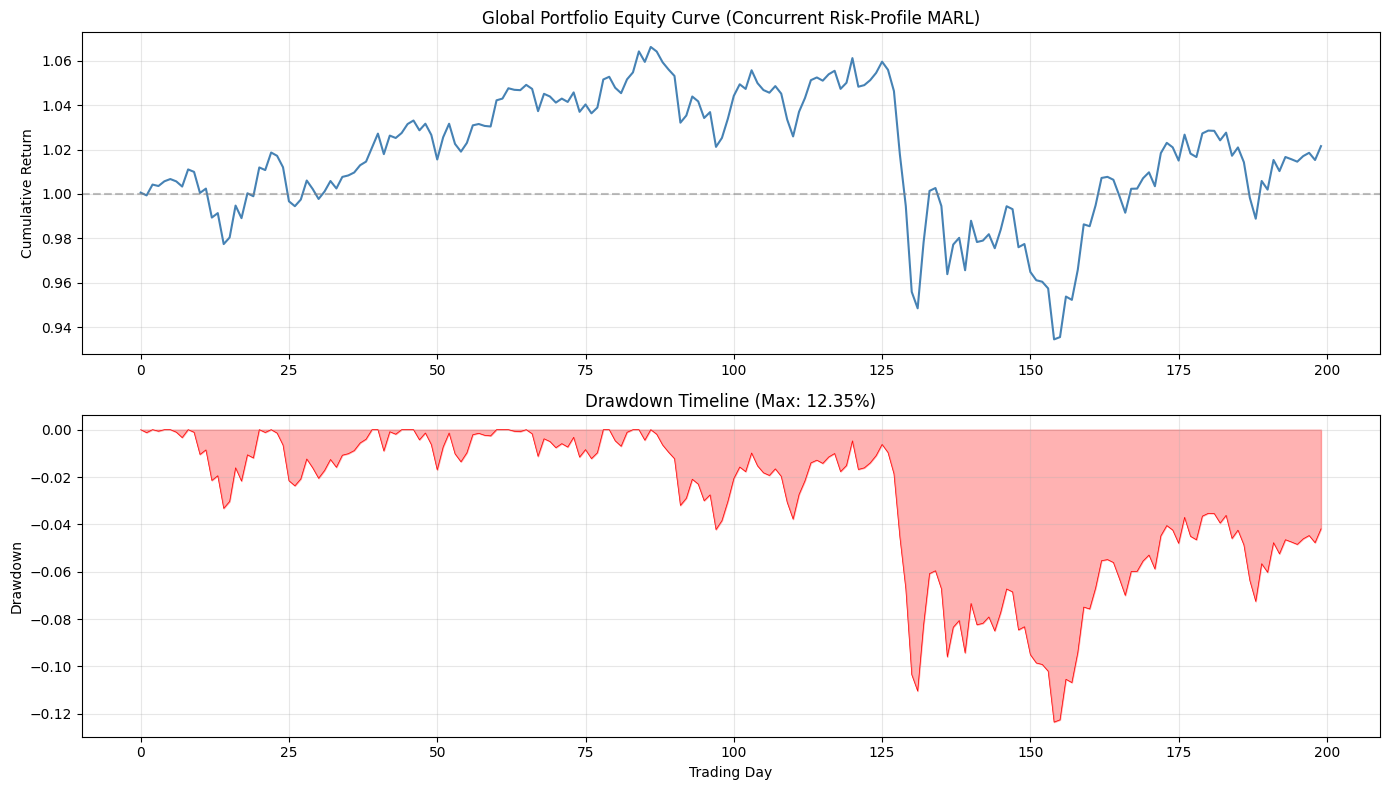

In [19]:
# Drawdown timeline
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

cum_ret = np.cumprod(1 + base_returns)
axes[0].plot(cum_ret, color='steelblue', linewidth=1.5)
axes[0].set_ylabel('Cumulative Return')
axes[0].set_title('Global Portfolio Equity Curve (Concurrent Risk-Profile MARL)')
axes[0].axhline(1.0, color='grey', linestyle='--', alpha=0.5)
axes[0].grid(alpha=0.3)

peak = np.maximum.accumulate(cum_ret)
dd_series = (peak - cum_ret) / peak
axes[1].fill_between(range(len(dd_series)), 0, -dd_series, color='red', alpha=0.3)
axes[1].plot(range(len(dd_series)), -dd_series, color='red', linewidth=0.5)
axes[1].set_xlabel('Trading Day')
axes[1].set_ylabel('Drawdown')
axes[1].set_title(f'Drawdown Timeline (Max: {eval_result["max_drawdown"]:.2%})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 8b: Return Distribution Analysis — Skewness & Kurtosis

Sharpe assumes returns are roughly Gaussian, but real strategies often have **fat tails**
(excess kurtosis > 0) and **asymmetric** payoffs (skewness ≠ 0). Right-skew is desirable
(more upside surprises), left-skew implies dangerous tail risk. Excess kurtosis above 3
flags a leptokurtic distribution where extreme moves are more frequent than the normal
model predicts.

We compare the daily-return distributions of all five strategies:

| Strategy | Description |
|----------|-------------|
| Staged MARL | 3-phase curriculum (this notebook, Section 5b) |
| Concurrent MARL | All-at-once training (Section 5) |
| Equal-Weight | 1/N rebalanced daily |
| MVO | Mean-Variance Optimisation (long-only, fixed weights) |
| Risk Parity | Inverse-volatility weights |


In [ ]:
# --- Build baseline daily returns over the same evaluation window ---
def _baseline_returns(weights):
    """Apply fixed weights (no rebalancing assumed each day to fixed weights) over price_df.
    Returns daily portfolio returns sliced to the same length as the MARL eval window."""
    pct = price_df.pct_change().dropna()
    pr = (pct.values @ weights)
    eval_len = min(len(pr), len(staged_eval['global_returns']))
    return pr[-eval_len:]

n = len(tickers)

# Equal-weight 1/N
ew_w = np.ones(n) / n
ew_returns = _baseline_returns(ew_w)

# Mean-Variance Optimisation (long-only, no shorting; closed-form using mu and Sigma)
mu = price_df.pct_change().dropna().mean().values
Sigma = price_df.pct_change().dropna().cov().values
try:
    inv_S = np.linalg.pinv(Sigma + 1e-6 * np.eye(n))
    raw = inv_S @ mu
    raw = np.clip(raw, 0, None)
    if raw.sum() < 1e-8:
        raw = np.ones(n)
    mvo_w = raw / raw.sum()
except np.linalg.LinAlgError:
    mvo_w = ew_w
mvo_returns = _baseline_returns(mvo_w)

# Risk Parity — inverse-volatility weights
vols = price_df.pct_change().dropna().std().values
inv_vol = 1.0 / (vols + 1e-8)
rp_w = inv_vol / inv_vol.sum()
rp_returns = _baseline_returns(rp_w)

# Strategy return series (all length-aligned to MARL eval)
strategies = {
    'Staged MARL':     np.asarray(staged_eval['global_returns']),
    'Concurrent MARL': np.asarray(eval_result['global_returns']),
    'Equal-Weight':    ew_returns,
    'MVO':             mvo_returns,
    'Risk Parity':     rp_returns,
}
strat_colors = {'Staged MARL': '#1f77b4', 'Concurrent MARL': '#ff7f0e',
                'Equal-Weight': '#2ca02c', 'MVO': '#9467bd', 'Risk Parity': '#8c564b'}

# Skewness + excess kurtosis
dist_stats = {}
for name, r in strategies.items():
    dist_stats[name] = {
        'mean':     float(np.mean(r)),
        'std':      float(np.std(r)),
        'skew':     float(stats.skew(r)),
        'ex_kurt':  float(stats.kurtosis(r, fisher=True)),  # fisher=True ⇒ normal=0
    }

# --- Figure A: 2x2 grid ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Return Distribution Analysis — Skewness & Kurtosis', fontsize=14, fontweight='bold')

# (a) Histograms + KDE + normal fit on Staged
ax = axes[0, 0]
for name, r in strategies.items():
    ax.hist(r, bins=40, density=True, color=strat_colors[name], alpha=0.30, label=name)
    try:
        sns.kdeplot(r, ax=ax, color=strat_colors[name], lw=1.4)
    except Exception:
        pass
sm_r = strategies['Staged MARL']
xs = np.linspace(sm_r.min(), sm_r.max(), 300)
ax.plot(xs, stats.norm.pdf(xs, sm_r.mean(), sm_r.std() + 1e-12),
        color='black', ls='--', lw=1.5, label='Normal fit (Staged)')
ax.set_title('Daily-Return Distributions'); ax.set_xlabel('Daily return')
ax.set_ylabel('Density'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (b) Q-Q plot for Staged MARL
ax = axes[0, 1]
stats.probplot(sm_r, dist='norm', plot=ax)
ax.set_title('Q-Q Plot — Staged MARL vs Normal'); ax.grid(alpha=0.3)

# (c) Skewness bar chart
ax = axes[1, 0]
names = list(strategies.keys())
skews = [dist_stats[n]['skew'] for n in names]
bar_colors = ['green' if s > 0 else 'red' for s in skews]
bars = ax.bar(names, skews, color=bar_colors, alpha=0.8)
for b, s in zip(bars, skews):
    ax.text(b.get_x() + b.get_width()/2, s, f"{s:+.3f}", ha='center',
            va='bottom' if s >= 0 else 'top', fontsize=9)
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Skewness  (>0 ⇒ right-skew, more upside surprises)')
ax.tick_params(axis='x', rotation=20); ax.grid(alpha=0.3, axis='y')

# (d) Excess kurtosis bar chart
ax = axes[1, 1]
ks = [dist_stats[n]['ex_kurt'] for n in names]
bar_colors = ['orange' if k > 3 else 'steelblue' for k in ks]
bars = ax.bar(names, ks, color=bar_colors, alpha=0.85)
for b, k in zip(bars, ks):
    ax.text(b.get_x() + b.get_width()/2, k, f"{k:+.2f}", ha='center',
            va='bottom' if k >= 0 else 'top', fontsize=9)
ax.axhline(0, color='black', lw=0.5, label='Normal (0)')
ax.axhline(3, color='red', ls='--', lw=1, label='Leptokurtic threshold (3)')
ax.set_title('Excess Kurtosis  (>3 ⇒ fat tails)')
ax.tick_params(axis='x', rotation=20); ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('return_distribution_analysis.png', dpi=140, bbox_inches='tight')
plt.show()

# --- Figure B: summary table ---
print("=" * 110)
print(f"{'Strategy':<18} {'Mean':>10} {'Std':>10} {'Skewness':>10} {'ExKurt':>10}   Interpretation")
print("-" * 110)
for n_ in names:
    s = dist_stats[n_]
    if s['skew'] > 0.1:
        interp = "Right-skewed (positive)"
    elif s['skew'] < -0.1:
        interp = "Left-skewed (negative — tail risk)"
    else:
        interp = "Approximately symmetric"
    interp += " + Fat tails" if s['ex_kurt'] > 3 else " + Thin tails"
    print(f"{n_:<18} {s['mean']*100:>9.3f}% {s['std']*100:>9.3f}% "
          f"{s['skew']:>10.3f} {s['ex_kurt']:>10.3f}   {interp}")
print("=" * 110)
print("Saved: return_distribution_analysis.png")


---
## Section 9: Results Summary

### Architecture
- **Universe**: 100-stock S&P 500 → **smart-selected to 50** via stratified beta sampling (Section 1).
- **Workers**: Risk-profile (Safe/Neutral/Risky) with mathematically divergent reward functions and Cash asset.
- **Manager**: Worker-aware observation **plus** 7-dim market-stress context, with stress + drawdown reward penalties (Section 2).
- **Network**: EIIE upgraded with LayerNorm + Dropout(0.1) + extra-context concatenation.

### Experiments shipped in this notebook
1. **Concurrent training** (200 ep) and **Staged training** (200+160+80 = 440 ep) — Sections 5 & 5b.
2. **Drawdown comparison figure** — `drawdown_comparison.png` (Section 5b).
3. **Walk-forward validation** across Bull/COVID/Recovery/Bear regimes (Section 6).
4. **Lambda ablation** — λ ∈ {0.0, 0.1, 0.35, 0.5, 1.0} for **both** training regimes — `lambda_ablation_comparison.png` (Section 7).
5. **Null hypothesis test** — Real vs Shuffled vs Zero lexical matrix under staged training — `random_control_experiment.png` (Section 7b).
6. **Drawdown decomposition** + **return-distribution analysis** (skewness, excess kurtosis, Q-Q plot) — `return_distribution_analysis.png` (Sections 8 & 8b).

### Why staged training
The Manager allocates across Workers whose policies are themselves still moving in concurrent
training, which creates a non-stationary target. Staged curriculum (Workers → Manager → Joint)
removes that non-stationarity in the early phases and the joint phase only fine-tunes around an
already-coordinated baseline. Section 5b reports whether this translates to better Sharpe / lower
MaxDD on this universe.

### What the null-hypothesis test tells us
The lexical penalty has the form $\\lambda \\cdot w^T S w$. By matching condition B (shuffled S
with identical statistics) against A (real S), any out-performance of A is attributable to the
**semantic identity** of each ticker — not the bare quadratic form.


In [ ]:
# --- Aggregate everything into a single results JSON ---
def _scalar(v):
    if isinstance(v, (np.floating, np.integer)):
        return float(v)
    if isinstance(v, np.ndarray):
        return v.tolist()
    return v


def _eval_summary(ev):
    return {
        'total_return': float(ev['total_return']),
        'sharpe':       float(ev['sharpe']),
        'sortino':      float(ev['sortino']),
        'max_drawdown': float(ev['max_drawdown']),
        'cvar_95':      float(ev['cvar_95']),
        'calmar':       float(ev['calmar']),
        'avg_allocation': {n: float(ev['avg_allocation'][i])
                           for i, n in enumerate(['Safe', 'Neutral', 'Risky'])},
        'worker_results': {n: {k: float(v) for k, v in wr.items()}
                           for n, wr in ev['worker_results'].items()},
    }


results = {
    'selection': {
        'universe_size':     int(selection_summary['universe_size']),
        'pool_sizes_before': selection_summary['pool_sizes_before'],
        'pool_sizes_after':  selection_summary['pool_sizes_after'],
        'allocation':        selection_summary['allocation'],
        'per_pool_selected': selection_summary['per_pool_selected'],
    },
    'beta_classification': {t: {'beta': float(betas[t]), 'profile': beta_labels[t]} for t in tickers},
    'risk_pools': {k: list(v) for k, v in risk_pools.items()},

    # Section 5: concurrent
    'concurrent_evaluation': _eval_summary(eval_result),

    # Section 5b: staged
    'staged_evaluation':     _eval_summary(staged_eval),

    # Section 6: walk-forward
    'walk_forward': {w: {'total_return': float(ev['total_return']),
                          'sharpe': float(ev['sharpe']),
                          'max_drawdown': float(ev['max_drawdown'])}
                     for w, ev in wf_results.items()},

    # Section 7: full ablation table (concurrent + staged x lambdas)
    'ablation_full': {
        regime: {str(l): _eval_summary(ev) for l, ev in lam_dict.items()}
        for regime, lam_dict in ablation_results.items()
    },

    # Section 7b: null hypothesis
    'random_control': {cn: _eval_summary(null_results[cn]) for cn in ['Real', 'Shuffled', 'Zero']},

    # Section 8b: skewness / kurtosis
    'distribution_stats': {n: {k: float(v) for k, v in s.items()} for n, s in dist_stats.items()},
}

os.makedirs('data/processed', exist_ok=True)
with open("data/processed/sp500_notebook_results.json", "w", encoding='utf-8') as f:
    json.dump(results, f, indent=2, default=_scalar)

print("Results saved to data/processed/sp500_notebook_results.json")
print(f"\nTotal notebook runtime: {time.time()-t0:.1f}s")


Results saved to data/processed/sp500_notebook_results.json

Total runtime: 5527.3s
